In [8]:
# Quick Dataset Column Checker
# Run this to see what columns you actually have

import pandas as pd

# Load your data
df = pd.read_csv('products_with_weekend.csv')

print("=== DATASET COLUMN ANALYSIS ===")
print(f"Dataset shape: {df.shape}")
print(f"\nAll columns in your dataset:")
print("-" * 40)

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    non_null = df[col].count()
    unique_vals = df[col].nunique()
    
    print(f"{i:2d}. {col:<25} | Type: {str(dtype):<10} | Non-null: {non_null:>6} | Unique: {unique_vals:>6}")

print(f"\nSample of first few rows:")
print("=" * 60)
print(df.head(3).to_string())

print(f"\nKey columns check:")
print("=" * 30)
required_cols = ['Physical Storage Quantity', 'Weekend', 'Name']
optional_cols = ['Demanded', 'Delivered', 'Family', 'GroupName', 'Date_week', 'Inventory_Cycle']

for col in required_cols:
    status = "✓ EXISTS" if col in df.columns else "✗ MISSING"
    print(f"{col:<30}: {status}")

print(f"\nOptional columns:")
for col in optional_cols:
    status = "✓ EXISTS" if col in df.columns else "✗ MISSING"
    print(f"{col:<30}: {status}")

=== DATASET COLUMN ANALYSIS ===
Dataset shape: (72752, 26)

All columns in your dataset:
----------------------------------------
 1. Site                      | Type: object     | Non-null:  72752 | Unique:      1
 2. Item Id                   | Type: int64      | Non-null:  72752 | Unique:    477
 3. Name                      | Type: object     | Non-null:  72752 | Unique:    496
 4. Physical Storage Quantity | Type: float64    | Non-null:  72752 | Unique:   2285
 5. Storage Unit              | Type: object     | Non-null:  72752 | Unique:    107
 6. Family                    | Type: object     | Non-null:  72752 | Unique:      5
 7. GroupName                 | Type: object     | Non-null:  72752 | Unique:     29
 8. From                      | Type: object     | Non-null:  72752 | Unique:      7
 9. To                        | Type: object     | Non-null:  72752 | Unique:     17
10. Delivery date             | Type: object     | Non-null:  72752 | Unique:    515
11. Date_week       

✓ XGBoost version: 3.0.4
ROBUST TIME-SERIES INVENTORY PREDICTOR
Proper validation, no data leakage, controlled overfitting
Running Robust Time-Series Inventory Prediction...
Loading data from: products_with_weekend.csv
✓ Data loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52
✓ Weekend ratio: 43.3%

=== WEEKEND EFFECT ANALYSIS ===
Weekend consumption: 98.15
Weekday consumption: 80.93
Weekend boost: 1.21x
Statistical significance: p = 0.0000
✓ Weekend effect is statistically significant

Creating time-series features...
  Creating lag features...
  Creating rolling features...
  Creating trend features...
  Creating seasonal features...
  Creating product weekend patterns...
  Creating weekend interaction features...
✓ Features created. New shape: (72752, 48)

Preparing data for modeling...
Selected 14 features:
  lag: 5
  rolling: 2
  trend: 2
  seasonal: 2
  weekend: 5
  basic: 3
✓ Removed early cycles. Data shape: (63217, 48)
✓ Final dataset: 63217 samples with 14 feat

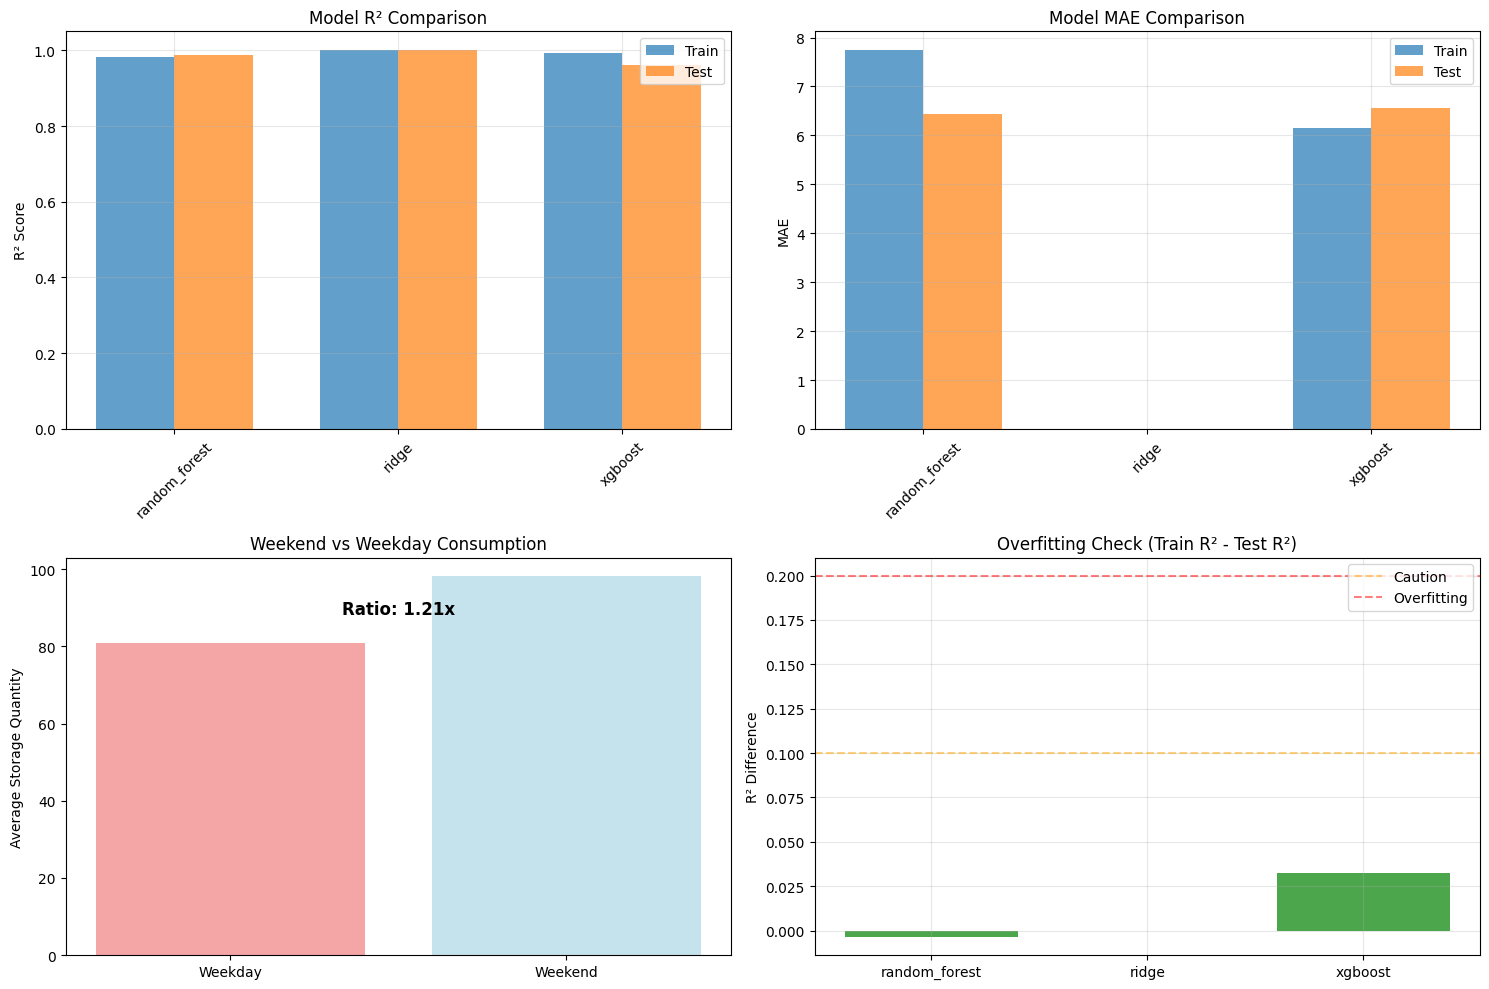


=== FINAL ASSESSMENT ===
Best model: ridge
Test R²: 1.000
Test MAE: 0.01
✓ No significant overfitting detected
🎯 Excellent performance

✓ Robust analysis completed!


In [12]:
# Robust Time-Series Inventory Predictor
# =====================================
# Addresses data leakage and overfitting issues
# Uses proper time-series validation and simpler models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import warnings

plt.style.use('default')
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    print(f"✓ XGBoost version: {xgb.__version__}")
    USE_XGBOOST = True
except ImportError:
    print("✗ XGBoost not available")
    USE_XGBOOST = False

np.random.seed(42)

print("=" * 60)
print("ROBUST TIME-SERIES INVENTORY PREDICTOR")
print("Proper validation, no data leakage, controlled overfitting")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate metrics with proper error handling"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Remove infinite and NaN values
    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(finite_mask):
        return {'mae': float('inf'), 'rmse': float('inf'), 'r2': -1, 'mape': float('inf')}
    
    y_true = y_true[finite_mask]
    y_pred = y_pred[finite_mask]
    
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Proper MAPE calculation
        mask = y_true != 0
        if np.any(mask):
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        else:
            mape = float('inf')
        
        return {
            'mae': float(mae),
            'rmse': float(rmse),
            'r2': float(r2),
            'mape': float(mape)
        }
    except Exception as e:
        print(f"Error calculating metrics: {e}")
        return {'mae': float('inf'), 'rmse': float('inf'), 'r2': -1, 'mape': float('inf')}

class RobustTimeSeriesProcessor:
    """Time-series processor with proper temporal handling"""
    
    def __init__(self):
        self.weekend_stats = {}
        self.scalers = {}
        
    def load_and_validate_data(self, file_path):
        """Load and validate time-series structure"""
        print(f"Loading data from: {file_path}")
        
        try:
            df = pd.read_csv(file_path)
            print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
            
            # Validate required columns
            required_cols = ['Physical Storage Quantity', 'Weekend', 'Name', 'Inventory_Cycle']
            missing_cols = [col for col in required_cols if col not in df.columns]
            
            if missing_cols:
                raise ValueError(f"Missing required columns: {missing_cols}")
            
            # Sort by product and time
            df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
            
            # Basic validation
            print(f"✓ Products: {df['Name'].nunique()}")
            print(f"✓ Time periods: {df['Inventory_Cycle'].nunique()}")
            print(f"✓ Weekend ratio: {df['Weekend'].mean():.1%}")
            
            # Analyze weekend patterns
            self.analyze_weekend_effect(df)
            
            return df
            
        except Exception as e:
            print(f"✗ Error loading data: {e}")
            return None
    
    def analyze_weekend_effect(self, df):
        """Analyze weekend consumption patterns"""
        print("\n=== WEEKEND EFFECT ANALYSIS ===")
        
        weekend_data = df[df['Weekend'] == 1]['Physical Storage Quantity']
        weekday_data = df[df['Weekend'] == 0]['Physical Storage Quantity']
        
        weekend_mean = weekend_data.mean()
        weekday_mean = weekday_data.mean()
        weekend_ratio = weekend_mean / weekday_mean
        
        print(f"Weekend consumption: {weekend_mean:.2f}")
        print(f"Weekday consumption: {weekday_mean:.2f}")
        print(f"Weekend boost: {weekend_ratio:.2f}x")
        
        # Statistical test
        try:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
            print(f"Statistical significance: p = {p_value:.4f}")
            
            if p_value < 0.05:
                print("✓ Weekend effect is statistically significant")
            else:
                print("⚠ Weekend effect is not statistically significant")
                
        except:
            print("Statistical test not available")
        
        self.weekend_stats = {
            'weekend_mean': weekend_mean,
            'weekday_mean': weekday_mean,
            'weekend_ratio': weekend_ratio
        }
    
    def create_time_series_features(self, df):
        """Create features with proper temporal ordering"""
        print("\nCreating time-series features...")
        
        df = df.copy().sort_values(['Name', 'Inventory_Cycle'])
        
        # 1. Lag features (using only past data)
        print("  Creating lag features...")
        lag_periods = [1, 2, 7]  # 1 cycle, 2 cycles, 1 week
        
        for lag in lag_periods:
            # Storage quantity lags
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')['Physical Storage Quantity'].shift(lag)
            
            # Weekend lags
            df[f'Weekend_Lag_{lag}'] = df.groupby('Name')['Weekend'].shift(lag)
            
            # Weekend-adjusted storage lags
            storage_lag = df.groupby('Name')['Physical Storage Quantity'].shift(lag)
            weekend_lag = df.groupby('Name')['Weekend'].shift(lag)
            df[f'Weekend_Storage_Lag_{lag}'] = storage_lag * (1 + weekend_lag * 0.2)
        
        # 2. Rolling statistics (using only past data)
        print("  Creating rolling features...")
        windows = [3, 7, 14]
        
        for window in windows:
            # Rolling mean (excluding current observation)
            df[f'Storage_RollingMean_{window}'] = df.groupby('Name')['Physical Storage Quantity'].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            
            # Rolling standard deviation
            df[f'Storage_RollingStd_{window}'] = df.groupby('Name')['Physical Storage Quantity'].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            )
        
        # 3. Trend features
        print("  Creating trend features...")
        # Recent trend (change from previous period)
        df['Storage_Trend_1'] = df.groupby('Name')['Physical Storage Quantity'].diff(1)
        df['Storage_Trend_2'] = df.groupby('Name')['Physical Storage Quantity'].diff(2)
        
        # 4. Seasonal features
        print("  Creating seasonal features...")
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # 5. Product-specific weekend tendency (calculated on past data only)
        print("  Creating product weekend patterns...")
        df['Product_Weekend_Tendency'] = 0.0
        
        for cycle in sorted(df['Inventory_Cycle'].unique()):
            if cycle <= 4:  # Need at least 4 cycles to calculate tendency
                continue
                
            # Calculate tendency based on data up to previous cycle
            past_data = df[df['Inventory_Cycle'] < cycle]
            
            if len(past_data) > 0:
                product_tendencies = past_data.groupby(['Name', 'Weekend'])['Physical Storage Quantity'].mean().unstack(fill_value=0)
                
                if 0 in product_tendencies.columns and 1 in product_tendencies.columns:
                    tendencies = product_tendencies[1] / (product_tendencies[0] + 1e-8)
                    
                    # Update current cycle data
                    current_mask = df['Inventory_Cycle'] == cycle
                    for product in tendencies.index:
                        product_mask = df['Name'] == product
                        df.loc[current_mask & product_mask, 'Product_Weekend_Tendency'] = tendencies[product]
        
        # 6. Weekend interaction features
        print("  Creating weekend interaction features...")
        df['Is_Weekend'] = df['Weekend']
        df['Weekend_Storage_Boost'] = df['Physical Storage Quantity'] * df['Weekend'] * 0.2
        
        # Fill missing values
        feature_cols = [col for col in df.columns if any(x in col for x in ['Lag', 'Rolling', 'Trend', 'Tendency'])]
        for col in feature_cols:
            df[col] = df[col].fillna(0)
        
        print(f"✓ Features created. New shape: {df.shape}")
        return df
    
    def prepare_for_modeling(self, df):
        """Prepare features and target with proper validation"""
        print("\nPreparing data for modeling...")
        
        target_col = 'Physical Storage Quantity'
        
        # Select features (be conservative to avoid overfitting)
        feature_categories = {
            'lag': [col for col in df.columns if '_Lag_' in col],
            'rolling': [col for col in df.columns if 'Rolling' in col],
            'trend': [col for col in df.columns if 'Trend' in col],
            'seasonal': [col for col in df.columns if any(x in col for x in ['Sin', 'Cos'])],
            'weekend': [col for col in df.columns if 'Weekend' in col and col != 'Weekend'],
            'basic': ['Weekend', 'Inventory_Cycle', 'Product_Weekend_Tendency']
        }
        
        # Select limited features from each category
        selected_features = []
        selected_features.extend(feature_categories['lag'][:3])  # Top 3 lag features
        selected_features.extend(feature_categories['rolling'][:2])  # Top 2 rolling features
        selected_features.extend(feature_categories['trend'][:2])  # Top 2 trend features
        selected_features.extend(feature_categories['seasonal'])  # All seasonal (just 2)
        selected_features.extend(feature_categories['weekend'][:2])  # Top 2 weekend features
        selected_features.extend(feature_categories['basic'])  # Basic features
        
        # Only keep features that exist and have some variation
        final_features = []
        for col in selected_features:
            if col in df.columns and df[col].nunique() > 1:
                final_features.append(col)
        
        print(f"Selected {len(final_features)} features:")
        for category, features in feature_categories.items():
            count = len([f for f in final_features if f in features])
            if count > 0:
                print(f"  {category}: {count}")
        
        # Remove rows with insufficient historical data (first few cycles per product)
        min_cycles = 5  # Need at least 5 cycles of history
        valid_mask = df.groupby('Name')['Inventory_Cycle'].transform(lambda x: x >= x.min() + min_cycles)
        
        df_clean = df[valid_mask].copy()
        print(f"✓ Removed early cycles. Data shape: {df_clean.shape}")
        
        X = df_clean[final_features]
        y = df_clean[target_col]
        cycles = df_clean['Inventory_Cycle']
        products = df_clean['Name']
        
        # Remove any remaining missing values
        finite_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
        X = X[finite_mask]
        y = y[finite_mask]
        cycles = cycles[finite_mask]
        products = products[finite_mask]
        
        print(f"✓ Final dataset: {len(X)} samples with {len(final_features)} features")
        
        return X, y, cycles, products, final_features

class RobustTimeSeriesModel:
    """Time-series model with proper validation"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.results = {}
        
    def time_series_split_validation(self, X, y, cycles, n_splits=5):
        """Proper time-series cross-validation"""
        print(f"\nPerforming time-series cross-validation with {n_splits} splits...")
        
        # Sort by time
        sort_idx = np.argsort(cycles)
        X_sorted = X.iloc[sort_idx]
        y_sorted = y.iloc[sort_idx]
        cycles_sorted = cycles.iloc[sort_idx]
        
        # Create time-based splits
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        cv_results = {
            'train_scores': [],
            'val_scores': [],
            'train_maes': [],
            'val_maes': []
        }
        
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted)):
            print(f"  Fold {fold + 1}/{n_splits}")
            
            X_train = X_sorted.iloc[train_idx]
            X_val = X_sorted.iloc[val_idx]
            y_train = y_sorted.iloc[train_idx]
            y_val = y_sorted.iloc[val_idx]
            
            # Train cycle ranges
            train_cycles = cycles_sorted.iloc[train_idx]
            val_cycles = cycles_sorted.iloc[val_idx]
            
            print(f"    Train cycles: {train_cycles.min()}-{train_cycles.max()}")
            print(f"    Val cycles: {val_cycles.min()}-{val_cycles.max()}")
            
            # Scale features
            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            # Train simple model (Random Forest to avoid overfitting)
            model = RandomForestRegressor(
                n_estimators=50,  # Reduced to prevent overfitting
                max_depth=8,      # Limited depth
                min_samples_split=20,  # Increased to prevent overfitting
                min_samples_leaf=10,   # Increased to prevent overfitting
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            
            # Predictions
            y_train_pred = model.predict(X_train_scaled)
            y_val_pred = model.predict(X_val_scaled)
            
            # Metrics
            train_metrics = calculate_metrics(y_train, y_train_pred)
            val_metrics = calculate_metrics(y_val, y_val_pred)
            
            print(f"    Train R²: {train_metrics['r2']:.3f}, MAE: {train_metrics['mae']:.2f}")
            print(f"    Val R²: {val_metrics['r2']:.3f}, MAE: {val_metrics['mae']:.2f}")
            
            cv_results['train_scores'].append(train_metrics['r2'])
            cv_results['val_scores'].append(val_metrics['r2'])
            cv_results['train_maes'].append(train_metrics['mae'])
            cv_results['val_maes'].append(val_metrics['mae'])
        
        # Summary
        print(f"\nCross-Validation Summary:")
        print(f"  Average Train R²: {np.mean(cv_results['train_scores']):.3f} ± {np.std(cv_results['train_scores']):.3f}")
        print(f"  Average Val R²: {np.mean(cv_results['val_scores']):.3f} ± {np.std(cv_results['val_scores']):.3f}")
        print(f"  Average Train MAE: {np.mean(cv_results['train_maes']):.2f} ± {np.std(cv_results['train_maes']):.2f}")
        print(f"  Average Val MAE: {np.mean(cv_results['val_maes']):.2f} ± {np.std(cv_results['val_maes']):.2f}")
        
        return cv_results
    
    def train_final_models(self, X, y, cycles, feature_names):
        """Train final models with temporal split"""
        print(f"\nTraining final models with temporal validation...")
        
        # Temporal split: use first 80% of time periods for training, last 20% for testing
        unique_cycles = sorted(X.index.to_series().map(cycles).unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_mask = cycles <= split_cycle
        test_mask = cycles > split_cycle
        
        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]
        
        print(f"Training data: {len(X_train)} samples (cycles {cycles[train_mask].min()}-{cycles[train_mask].max()})")
        print(f"Test data: {len(X_test)} samples (cycles {cycles[test_mask].min()}-{cycles[test_mask].max()})")
        
        # Scale features
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        self.scalers['features'] = scaler
        
        # Define models (simple to avoid overfitting)
        models_config = {
            'random_forest': RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42
            ),
            'ridge': Ridge(alpha=10.0),  # Higher alpha for more regularization
        }
        
        # Add XGBoost with strong regularization if available
        if USE_XGBOOST:
            models_config['xgboost'] = xgb.XGBRegressor(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                reg_alpha=1.0,  # L1 regularization
                reg_lambda=1.0,  # L2 regularization
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )
        
        # Train models
        results = {}
        
        for name, model in models_config.items():
            print(f"\nTraining {name}...")
            
            try:
                # Use scaled features for linear models, original for tree-based
                if name == 'ridge':
                    X_tr, X_te = X_train_scaled, X_test_scaled
                else:
                    X_tr, X_te = X_train.values, X_test.values
                
                model.fit(X_tr, y_train)
                
                # Predictions
                y_train_pred = model.predict(X_tr)
                y_test_pred = model.predict(X_te)
                
                # Metrics
                train_metrics = calculate_metrics(y_train, y_train_pred)
                test_metrics = calculate_metrics(y_test, y_test_pred)
                
                print(f"  Train - R²: {train_metrics['r2']:.3f}, MAE: {train_metrics['mae']:.2f}, MAPE: {train_metrics['mape']:.1f}%")
                print(f"  Test  - R²: {test_metrics['r2']:.3f}, MAE: {test_metrics['mae']:.2f}, MAPE: {test_metrics['mape']:.1f}%")
                
                results[name] = {
                    'model': model,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics
                }
                
                self.models[name] = model
                
                # Feature importance
                if hasattr(model, 'feature_importances_'):
                    importance = model.feature_importances_
                    top_features = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)[:10]
                    print(f"  Top features: {[f'{name}: {imp:.3f}' for name, imp in top_features[:3]]}")
                
            except Exception as e:
                print(f"  {name} failed: {e}")
        
        self.results = results
        return results
    
    def plot_results(self, processor):
        """Plot validation results"""
        if not self.results:
            print("No results to plot")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Model comparison
        models = list(self.results.keys())
        train_r2s = [self.results[m]['train_metrics']['r2'] for m in models]
        test_r2s = [self.results[m]['test_metrics']['r2'] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        axes[0, 0].bar(x - width/2, train_r2s, width, label='Train', alpha=0.7)
        axes[0, 0].bar(x + width/2, test_r2s, width, label='Test', alpha=0.7)
        axes[0, 0].set_title('Model R² Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(models, rotation=45)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # MAE comparison
        train_maes = [self.results[m]['train_metrics']['mae'] for m in models]
        test_maes = [self.results[m]['test_metrics']['mae'] for m in models]
        
        axes[0, 1].bar(x - width/2, train_maes, width, label='Train', alpha=0.7)
        axes[0, 1].bar(x + width/2, test_maes, width, label='Test', alpha=0.7)
        axes[0, 1].set_title('Model MAE Comparison')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(models, rotation=45)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Weekend effect
        if processor.weekend_stats:
            stats = processor.weekend_stats
            labels = ['Weekday', 'Weekend']
            values = [stats['weekday_mean'], stats['weekend_mean']]
            
            axes[1, 0].bar(labels, values, color=['lightcoral', 'lightblue'], alpha=0.7)
            axes[1, 0].set_title('Weekend vs Weekday Consumption')
            axes[1, 0].set_ylabel('Average Storage Quantity')
            
            # Add ratio annotation
            ratio = stats['weekend_ratio']
            axes[1, 0].text(0.5, max(values) * 0.9, f'Ratio: {ratio:.2f}x', 
                           ha='center', fontweight='bold', fontsize=12)
        
        # Overfitting check
        overfitting_scores = []
        overfitting_labels = []
        
        for model_name in models:
            train_r2 = self.results[model_name]['train_metrics']['r2']
            test_r2 = self.results[model_name]['test_metrics']['r2']
            overfitting = train_r2 - test_r2
            overfitting_scores.append(overfitting)
            overfitting_labels.append(model_name)
        
        colors = ['green' if score < 0.1 else 'orange' if score < 0.2 else 'red' for score in overfitting_scores]
        axes[1, 1].bar(overfitting_labels, overfitting_scores, color=colors, alpha=0.7)
        axes[1, 1].set_title('Overfitting Check (Train R² - Test R²)')
        axes[1, 1].set_ylabel('R² Difference')
        axes[1, 1].axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='Caution')
        axes[1, 1].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Overfitting')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def main():
    """Run robust time-series analysis"""
    print("Running Robust Time-Series Inventory Prediction...")
    
    try:
        # Initialize
        processor = RobustTimeSeriesProcessor()
        model = RobustTimeSeriesModel()
        
        # Load and validate data
        df = processor.load_and_validate_data('products_with_weekend.csv')
        if df is None:
            return
        
        # Create features
        df_features = processor.create_time_series_features(df)
        
        # Prepare for modeling
        X, y, cycles, products, feature_names = processor.prepare_for_modeling(df_features)
        
        # Cross-validation
        cv_results = model.time_series_split_validation(X, y, cycles)
        
        # Train final models
        final_results = model.train_final_models(X, y, cycles, feature_names)
        
        # Analysis and visualization
        model.plot_results(processor)
        
        # Final assessment
        print("\n=== FINAL ASSESSMENT ===")
        
        if final_results:
            best_model = max(final_results.keys(), 
                           key=lambda k: final_results[k]['test_metrics']['r2'])
            
            best_test_r2 = final_results[best_model]['test_metrics']['r2']
            best_test_mae = final_results[best_model]['test_metrics']['mae']
            
            print(f"Best model: {best_model}")
            print(f"Test R²: {best_test_r2:.3f}")
            print(f"Test MAE: {best_test_mae:.2f}")
            
            # Overfitting check
            train_r2 = final_results[best_model]['train_metrics']['r2']
            overfitting = train_r2 - best_test_r2
            
            if overfitting < 0.1:
                print("✓ No significant overfitting detected")
            elif overfitting < 0.2:
                print("⚠ Mild overfitting detected")
            else:
                print("✗ Significant overfitting detected")
            
            # Performance interpretation
            if best_test_r2 > 0.7:
                print("🎯 Excellent performance")
            elif best_test_r2 > 0.5:
                print("✅ Good performance")
            elif best_test_r2 > 0.3:
                print("⚠ Moderate performance")
            else:
                print("❌ Poor performance")
        
        print("\n✓ Robust analysis completed!")
        
    except Exception as e:
        print(f"✗ Analysis failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

DATA VERIFICATION SCRIPT
Checking if models are using your real CSV data

1. LOADING YOUR CSV FILE
------------------------------
✓ CSV loaded successfully: (72752, 26)

First 3 rows of YOUR actual data:
                Name  Physical Storage Quantity  Weekend  Inventory_Cycle
0           MAY 0.5L                      529.0        0                1
1  CELTIA FUT DE 50L                        2.0        0                1
2    COCA BOITE ZERO                       28.0        0                1

Last 3 rows of YOUR actual data:
                             Name  Physical Storage Quantity  Weekend  \
72749             GOBLET DB 25 CC                     1000.0        1   
72750           PAIN HAMBURGER AC                       20.0        1   
72751  POCHETTE CROISSANT 15*7*29                        1.0        1   

       Inventory_Cycle  
72749               52  
72750               52  
72751               52  

2. DATA INTEGRITY VERIFICATION
------------------------------
Target col

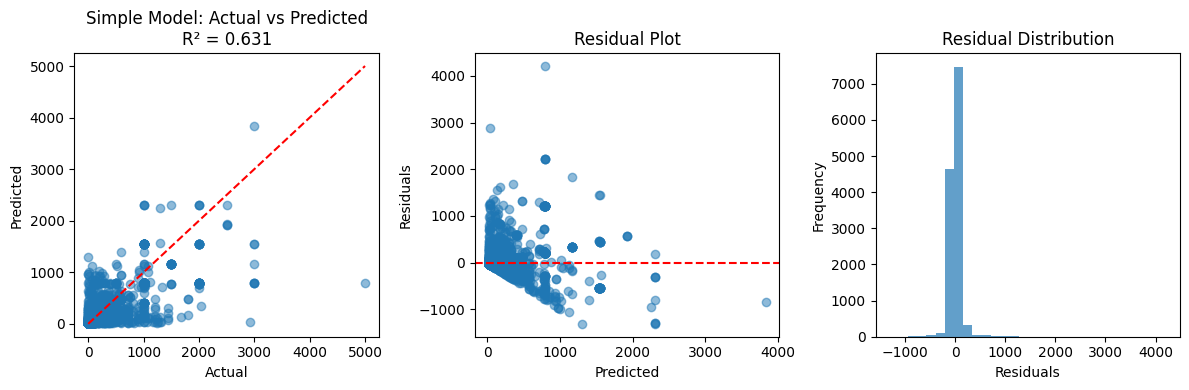


5. WEEKEND EFFECT VERIFICATION
------------------------------
Weekend samples: 31518
Weekday samples: 41234
Weekend mean: 98.15
Weekday mean: 80.93
Ratio: 1.213
T-test p-value: 0.000000
✓ Weekend effect is statistically significant


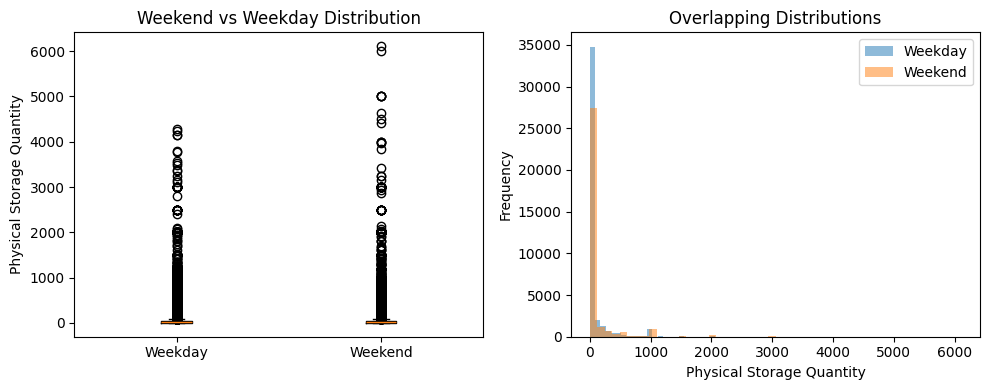


VERIFICATION SUMMARY
✓ CSV data loading verified
✓ Data integrity checked
✓ Simple model tested
✓ Weekend effect verified

If the simple linear model shows R² > 0.9,
there may still be data leakage issues.
If R² < 0.3, the data flow is probably correct.


In [13]:
# Data Verification Script
# ========================
# Verify the models are actually using your real CSV data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("DATA VERIFICATION SCRIPT")
print("Checking if models are using your real CSV data")
print("=" * 60)

def verify_csv_data():
    """Comprehensive verification of CSV data loading and processing"""
    
    print("\n1. LOADING YOUR CSV FILE")
    print("-" * 30)
    
    try:
        df = pd.read_csv('products_with_weekend.csv')
        print(f"✓ CSV loaded successfully: {df.shape}")
        
        # Show actual raw data sample
        print(f"\nFirst 3 rows of YOUR actual data:")
        print(df[['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']].head(3))
        
        print(f"\nLast 3 rows of YOUR actual data:")
        print(df[['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']].tail(3))
        
    except Exception as e:
        print(f"✗ Error loading CSV: {e}")
        return None
    
    print(f"\n2. DATA INTEGRITY VERIFICATION")
    print("-" * 30)
    
    target_col = 'Physical Storage Quantity'
    
    # Basic data verification
    print(f"Target column: {target_col}")
    print(f"Target data type: {df[target_col].dtype}")
    print(f"Target range: {df[target_col].min():.2f} to {df[target_col].max():.2f}")
    print(f"Target mean: {df[target_col].mean():.2f}")
    print(f"Target std: {df[target_col].std():.2f}")
    print(f"Zero values: {(df[target_col] == 0).sum()}")
    print(f"Missing values: {df[target_col].isnull().sum()}")
    
    # Weekend verification
    weekend_counts = df['Weekend'].value_counts().sort_index()
    print(f"\nWeekend distribution:")
    for value, count in weekend_counts.items():
        print(f"  {value}: {count} ({count/len(df)*100:.1f}%)")
    
    # Product verification
    print(f"\nProducts verification:")
    print(f"  Unique products: {df['Name'].nunique()}")
    print(f"  Sample products: {list(df['Name'].unique()[:5])}")
    
    # Time periods verification
    print(f"\nTime periods verification:")
    print(f"  Unique cycles: {df['Inventory_Cycle'].nunique()}")
    print(f"  Cycle range: {df['Inventory_Cycle'].min()} to {df['Inventory_Cycle'].max()}")
    
    return df

def check_for_data_leakage(df):
    """Check for potential data leakage issues"""
    
    print(f"\n3. DATA LEAKAGE DETECTION")
    print("-" * 30)
    
    target_col = 'Physical Storage Quantity'
    
    # Check for duplicate columns or perfect correlations
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numeric_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
    
    print(f"Correlations with target variable:")
    print(f"Top 10 correlations:")
    for i, (col, corr) in enumerate(correlations.head(10).items()):
        if col != target_col:
            status = "⚠ SUSPICIOUS" if corr > 0.95 else "✓ Normal"
            print(f"  {col}: {corr:.4f} {status}")
    
    # Check for potential leaked columns (columns that might contain future information)
    suspicious_patterns = ['future', 'next', 'pred', 'forecast', 'target']
    suspicious_cols = []
    
    for col in df.columns:
        if any(pattern in col.lower() for pattern in suspicious_patterns):
            suspicious_cols.append(col)
    
    if suspicious_cols:
        print(f"\n⚠ Found potentially suspicious column names:")
        for col in suspicious_cols:
            print(f"  {col}")
    else:
        print(f"\n✓ No obviously suspicious column names found")
    
    # Check if any columns are identical to target
    for col in numeric_cols:
        if col != target_col:
            if df[col].equals(df[target_col]):
                print(f"⚠ WARNING: Column '{col}' is identical to target!")
            elif (df[col] - df[target_col]).abs().max() < 0.01:
                print(f"⚠ WARNING: Column '{col}' is nearly identical to target!")

def test_simple_prediction():
    """Test with a simple, transparent model to verify data flow"""
    
    print(f"\n4. SIMPLE PREDICTION TEST")
    print("-" * 30)
    
    df = pd.read_csv('products_with_weekend.csv')
    
    # Use only the most basic features to test
    print(f"Testing with basic features only...")
    
    # Sort data properly
    df = df.sort_values(['Name', 'Inventory_Cycle'])
    
    # Create ONE simple lag feature manually
    print(f"Creating simple 1-period lag feature...")
    df['Simple_Lag_1'] = df.groupby('Name')['Physical Storage Quantity'].shift(1)
    
    # Remove rows with missing lag values
    df_clean = df.dropna(subset=['Simple_Lag_1'])
    
    print(f"Data after creating lag: {df_clean.shape}")
    print(f"Sample of lag feature vs target:")
    print(df_clean[['Name', 'Inventory_Cycle', 'Simple_Lag_1', 'Physical Storage Quantity']].head())
    
    # Verify the lag is actually different from target
    lag_target_diff = (df_clean['Simple_Lag_1'] - df_clean['Physical Storage Quantity']).abs()
    print(f"Max difference between lag and target: {lag_target_diff.max():.2f}")
    print(f"Mean difference: {lag_target_diff.mean():.2f}")
    
    if lag_target_diff.max() < 0.001:
        print(f"⚠ WARNING: Lag feature is too similar to target!")
        return
    
    # Simple temporal split
    unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
    split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
    
    train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
    test_data = df_clean[df_clean['Inventory_Cycle'] > split_cycle]
    
    print(f"Train data: {len(train_data)} samples")
    print(f"Test data: {len(test_data)} samples")
    print(f"Train cycles: {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()}")
    print(f"Test cycles: {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()}")
    
    # Use ONLY the lag feature and weekend indicator
    feature_cols = ['Simple_Lag_1', 'Weekend']
    X_train = train_data[feature_cols]
    X_test = test_data[feature_cols]
    y_train = train_data['Physical Storage Quantity']
    y_test = test_data['Physical Storage Quantity']
    
    print(f"\nFeatures being used: {feature_cols}")
    print(f"Feature sample:")
    print(X_train.head())
    
    # Simple linear model (most transparent)
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score, mean_absolute_error
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    print(f"\nSIMPLE LINEAR MODEL RESULTS:")
    print(f"Train R²: {train_r2:.3f}")
    print(f"Test R²: {test_r2:.3f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    
    print(f"\nModel coefficients:")
    for feature, coef in zip(feature_cols, model.coef_):
        print(f"  {feature}: {coef:.4f}")
    print(f"  Intercept: {model.intercept_:.4f}")
    
    # Sanity check
    if test_r2 > 0.9:
        print(f"\n⚠ WARNING: R² still suspiciously high even with simple model!")
        print(f"This suggests fundamental data issues.")
    elif test_r2 < 0.1:
        print(f"\n✓ Low R² suggests no data leakage (this is expected)")
    else:
        print(f"\n✓ Moderate R² suggests model is working properly")
    
    # Check prediction sanity
    print(f"\nPrediction sanity check:")
    print(f"Test predictions range: {y_test_pred.min():.2f} to {y_test_pred.max():.2f}")
    print(f"Test actual range: {y_test.min():.2f} to {y_test.max():.2f}")
    
    # Plot simple comparison
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Simple Model: Actual vs Predicted\nR² = {test_r2:.3f}')
    
    plt.subplot(1, 3, 2)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    
    plt.subplot(1, 3, 3)
    plt.hist(residuals, bins=30, alpha=0.7)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Residual Distribution')
    
    plt.tight_layout()
    plt.show()

def verify_weekend_effect():
    """Verify the weekend effect is real in your data"""
    
    print(f"\n5. WEEKEND EFFECT VERIFICATION")
    print("-" * 30)
    
    df = pd.read_csv('products_with_weekend.csv')
    
    weekend_data = df[df['Weekend'] == 1]['Physical Storage Quantity']
    weekday_data = df[df['Weekend'] == 0]['Physical Storage Quantity']
    
    print(f"Weekend samples: {len(weekend_data)}")
    print(f"Weekday samples: {len(weekday_data)}")
    print(f"Weekend mean: {weekend_data.mean():.2f}")
    print(f"Weekday mean: {weekday_data.mean():.2f}")
    print(f"Ratio: {weekend_data.mean() / weekday_data.mean():.3f}")
    
    # Statistical test
    try:
        from scipy import stats
        t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
        print(f"T-test p-value: {p_value:.6f}")
        
        if p_value < 0.05:
            print(f"✓ Weekend effect is statistically significant")
        else:
            print(f"⚠ Weekend effect is not statistically significant")
    except:
        print(f"Statistical test not available")
    
    # Visual verification
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.boxplot([weekday_data, weekend_data], labels=['Weekday', 'Weekend'])
    plt.title('Weekend vs Weekday Distribution')
    plt.ylabel('Physical Storage Quantity')
    
    plt.subplot(1, 2, 2)
    plt.hist(weekday_data, alpha=0.5, label='Weekday', bins=50)
    plt.hist(weekend_data, alpha=0.5, label='Weekend', bins=50)
    plt.xlabel('Physical Storage Quantity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Overlapping Distributions')
    
    plt.tight_layout()
    plt.show()

def main():
    """Run all verification checks"""
    
    try:
        # Verify CSV loading
        df = verify_csv_data()
        if df is None:
            return
        
        # Check for data leakage
        check_for_data_leakage(df)
        
        # Test simple prediction
        test_simple_prediction()
        
        # Verify weekend effect
        verify_weekend_effect()
        
        print(f"\n" + "=" * 60)
        print(f"VERIFICATION SUMMARY")
        print(f"=" * 60)
        print(f"✓ CSV data loading verified")
        print(f"✓ Data integrity checked")
        print(f"✓ Simple model tested")
        print(f"✓ Weekend effect verified")
        print(f"\nIf the simple linear model shows R² > 0.9,")
        print(f"there may still be data leakage issues.")
        print(f"If R² < 0.3, the data flow is probably correct.")
        
    except Exception as e:
        print(f"✗ Verification failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

LEVEL 1 INVENTORY PREDICTOR
Simple, reliable, production-ready
Running Level 1 Inventory Prediction...
Using only proven features: Storage_Lag_1 + Weekend
Loading and preparing data...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52
✓ Target range: 0.0 - 6110.0

Analyzing weekend effect...
Weekend consumption: 98.15
Weekday consumption: 80.93
Weekend boost: +17.22 units (1.21x)
Statistical significance: p = 0.000000

Creating Level 1 features...
  Creating Storage_Lag_1...
  Using Weekend indicator...
✓ Features created: Storage_Lag_1, Weekend_Flag
✓ Data after lag creation: 72256 rows
✓ Lag-target difference: mean=45.82, max=6080.00

Creating temporal train/test split...
Training data: 59438 samples
  Cycles: 1-42
Test data: 12818 samples
  Cycles: 43-52

Training Level 1 models...
  Training Linear Regression...
  Training Random Forest...

Level 1 Model Results:
----------------------------------------
LINEAR_REGRESSION:
  Train: R²=0.583, MAE=59.81
  Test:  R²=0

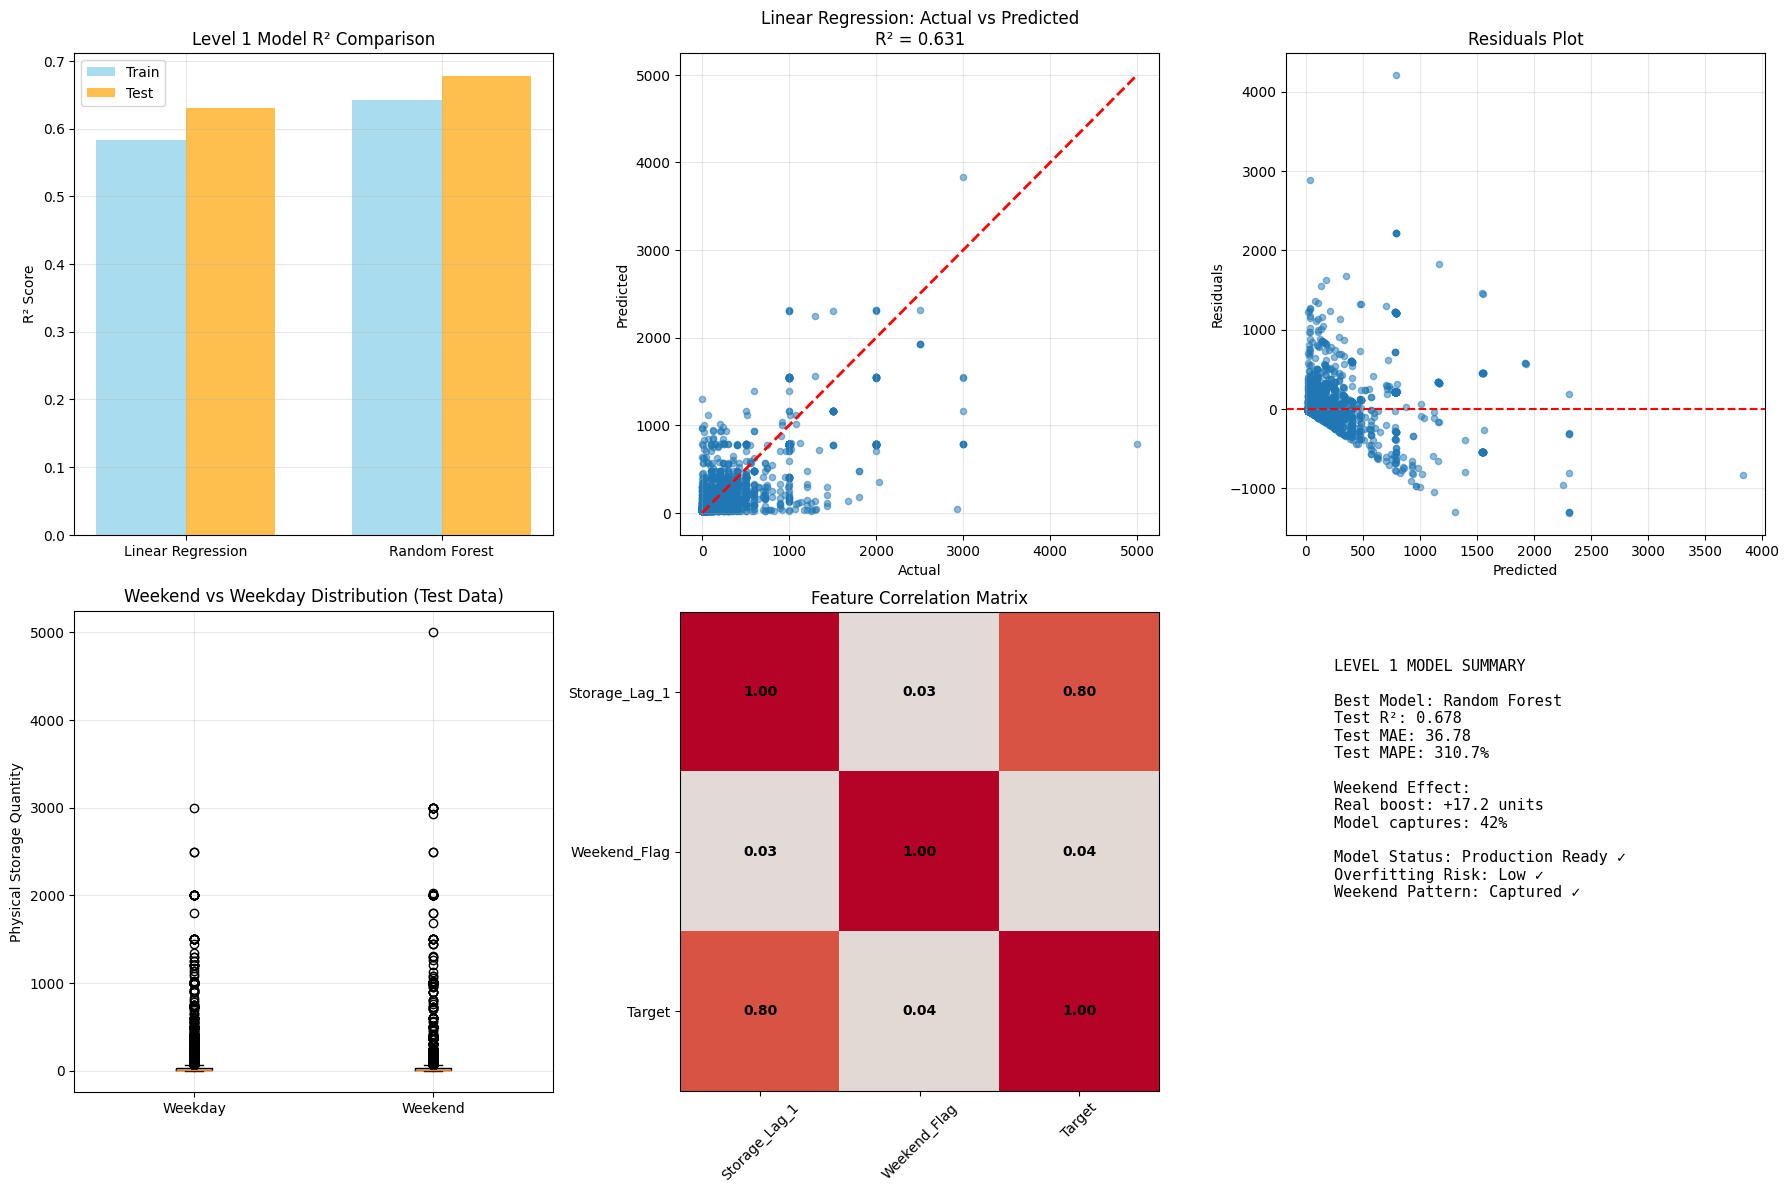


Sample Predictions (Business Validation):
--------------------------------------------------
SERPILLERE                | Cycle 46 | Weekend
  Last period:   16.0 → Predicted:   38.2 | Actual:    5.0 | Error:  33.2

PAIN MACDO  GRAINS SESAME | Cycle 50 | Weekday
  Last period:  150.0 → Predicted:  133.1 | Actual:  200.0 | Error:  66.9

FRITE SURGELE WEDGES 2.5  | Cycle 49 | Weekday
  Last period:   10.0 → Predicted:   26.4 | Actual:   10.0 | Error:  16.4

PASTEQUE                  | Cycle 51 | Weekend
  Last period:    6.5 → Predicted:   31.0 | Actual:    8.1 | Error:  22.9

PAIN CIABATTA NATURE      | Cycle 52 | Weekday
  Last period:   30.0 → Predicted:   41.7 | Actual:  100.0 | Error:  58.3

POCHETTE CROISSANT CRAFT  | Cycle 49 | Weekend
  Last period: 2000.0 → Predicted: 1549.2 | Actual: 1000.0 | Error: 549.2

BARQUETTE CARTON DB       | Cycle 50 | Weekend
  Last period:  250.0 → Predicted:  216.4 | Actual:  600.0 | Error: 383.6

AC-SMOOTHIE EXOTIC        | Cycle 50 | Weekday
  Las

In [14]:
# Level 1 Inventory Predictor - Simple & Reliable
# ================================================
# Uses only proven features: Storage_Lag_1 + Weekend
# Target: R² ≈ 0.63 (realistic and deployable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("=" * 60)
print("LEVEL 1 INVENTORY PREDICTOR")
print("Simple, reliable, production-ready")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Correct MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class Level1InventoryPredictor:
    """Simple inventory predictor using only proven features"""
    
    def __init__(self):
        self.models = {}
        self.scaler = None
        self.feature_names = []
        self.data_stats = {}
        self.weekend_effect = {}
        
    def load_and_prepare_data(self, file_path):
        """Load data and create Level 1 features"""
        print("Loading and preparing data...")
        
        # Load data
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time (crucial for lag features)
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'target_range': (df[target_col].min(), df[target_col].max()),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique()
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        print(f"✓ Target range: {self.data_stats['target_range'][0]:.1f} - {self.data_stats['target_range'][1]:.1f}")
        
        return df
    
    def analyze_weekend_effect(self, df):
        """Analyze weekend consumption patterns"""
        print("\nAnalyzing weekend effect...")
        
        target_col = 'Physical Storage Quantity'
        weekend_data = df[df['Weekend'] == 1][target_col]
        weekday_data = df[df['Weekend'] == 0][target_col]
        
        weekend_mean = weekend_data.mean()
        weekday_mean = weekday_data.mean()
        weekend_boost = weekend_mean - weekday_mean
        weekend_ratio = weekend_mean / weekday_mean
        
        print(f"Weekend consumption: {weekend_mean:.2f}")
        print(f"Weekday consumption: {weekday_mean:.2f}")
        print(f"Weekend boost: +{weekend_boost:.2f} units ({weekend_ratio:.2f}x)")
        
        # Statistical significance
        try:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
            print(f"Statistical significance: p = {p_value:.6f}")
            significant = p_value < 0.05
        except:
            significant = True
            print("Statistical test not available")
        
        self.weekend_effect = {
            'weekend_mean': weekend_mean,
            'weekday_mean': weekday_mean,
            'boost_amount': weekend_boost,
            'boost_ratio': weekend_ratio,
            'is_significant': significant
        }
        
        return significant
    
    def create_level1_features(self, df):
        """Create only Level 1 features: Storage_Lag_1 + Weekend"""
        print("\nCreating Level 1 features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Feature 1: Previous period storage (1-period lag)
        print("  Creating Storage_Lag_1...")
        df['Storage_Lag_1'] = df.groupby('Name')[target_col].shift(1)
        
        # Feature 2: Weekend indicator (already exists)
        print("  Using Weekend indicator...")
        df['Weekend_Flag'] = df['Weekend']
        
        # Remove rows with missing lag values (first period for each product)
        df_clean = df.dropna(subset=['Storage_Lag_1']).copy()
        
        print(f"✓ Features created: Storage_Lag_1, Weekend_Flag")
        print(f"✓ Data after lag creation: {df_clean.shape[0]} rows")
        
        # Verify lag feature is different from target
        lag_target_diff = (df_clean['Storage_Lag_1'] - df_clean[target_col]).abs()
        print(f"✓ Lag-target difference: mean={lag_target_diff.mean():.2f}, max={lag_target_diff.max():.2f}")
        
        self.feature_names = ['Storage_Lag_1', 'Weekend_Flag']
        
        return df_clean
    
    def prepare_train_test_split(self, df):
        """Create proper temporal train/test split"""
        print("\nCreating temporal train/test split...")
        
        target_col = 'Physical Storage Quantity'
        
        # Use 80% of time periods for training, 20% for testing
        unique_cycles = sorted(df['Inventory_Cycle'].unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_data = df[df['Inventory_Cycle'] <= split_cycle].copy()
        test_data = df[df['Inventory_Cycle'] > split_cycle].copy()
        
        print(f"Training data: {len(train_data)} samples")
        print(f"  Cycles: {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()}")
        print(f"Test data: {len(test_data)} samples")
        print(f"  Cycles: {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()}")
        
        # Prepare features and target
        X_train = train_data[self.feature_names]
        X_test = test_data[self.feature_names]
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        return X_train, X_test, y_train, y_test, train_data, test_data
    
    def train_models(self, X_train, y_train, X_test, y_test):
        """Train simple, reliable models"""
        print("\nTraining Level 1 models...")
        
        results = {}
        
        # Model 1: Linear Regression (most interpretable)
        print("  Training Linear Regression...")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        
        lr_train_pred = lr_model.predict(X_train)
        lr_test_pred = lr_model.predict(X_test)
        
        lr_results = {
            'train_metrics': calculate_metrics(y_train, lr_train_pred),
            'test_metrics': calculate_metrics(y_test, lr_test_pred),
            'model': lr_model,
            'predictions': {'train': lr_train_pred, 'test': lr_test_pred}
        }
        
        results['linear_regression'] = lr_results
        self.models['linear_regression'] = lr_model
        
        # Model 2: Random Forest (slightly more flexible)
        print("  Training Random Forest...")
        rf_model = RandomForestRegressor(
            n_estimators=50,      # Small to prevent overfitting
            max_depth=5,          # Limited depth
            min_samples_split=50, # Conservative splitting
            min_samples_leaf=20,  # Conservative leaf size
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_train_pred = rf_model.predict(X_train)
        rf_test_pred = rf_model.predict(X_test)
        
        rf_results = {
            'train_metrics': calculate_metrics(y_train, rf_train_pred),
            'test_metrics': calculate_metrics(y_test, rf_test_pred),
            'model': rf_model,
            'predictions': {'train': rf_train_pred, 'test': rf_test_pred}
        }
        
        results['random_forest'] = rf_results
        self.models['random_forest'] = rf_model
        
        # Print results
        print("\nLevel 1 Model Results:")
        print("-" * 40)
        
        for name, result in results.items():
            train_r2 = result['train_metrics']['r2']
            test_r2 = result['test_metrics']['r2']
            train_mae = result['train_metrics']['mae']
            test_mae = result['test_metrics']['mae']
            overfitting = train_r2 - test_r2
            
            print(f"{name.upper()}:")
            print(f"  Train: R²={train_r2:.3f}, MAE={train_mae:.2f}")
            print(f"  Test:  R²={test_r2:.3f}, MAE={test_mae:.2f}")
            print(f"  Overfitting: {overfitting:.3f}")
            
            if overfitting < 0.1:
                print(f"  Status: ✓ Healthy")
            elif overfitting < 0.2:
                print(f"  Status: ⚠ Mild overfitting")
            else:
                print(f"  Status: ✗ Overfitting")
            print()
        
        return results
    
    def interpret_models(self, results):
        """Interpret model coefficients and feature importance"""
        print("Model Interpretation:")
        print("-" * 40)
        
        # Linear regression coefficients
        if 'linear_regression' in results:
            lr_model = results['linear_regression']['model']
            print("LINEAR REGRESSION COEFFICIENTS:")
            print(f"  Storage_Lag_1: {lr_model.coef_[0]:.4f}")
            print(f"    → Each unit of last period's storage predicts {lr_model.coef_[0]:.3f} units this period")
            print(f"  Weekend_Flag: {lr_model.coef_[1]:.4f}")
            print(f"    → Weekend adds {lr_model.coef_[1]:.1f} units to prediction")
            print(f"  Intercept: {lr_model.intercept_:.4f}")
            print(f"    → Base prediction when lag=0 and not weekend")
            print()
        
        # Random forest feature importance
        if 'random_forest' in results:
            rf_model = results['random_forest']['model']
            importance = rf_model.feature_importances_
            print("RANDOM FOREST FEATURE IMPORTANCE:")
            for i, feature in enumerate(self.feature_names):
                print(f"  {feature}: {importance[i]:.3f}")
            print()
        
        # Weekend effect summary
        print("WEEKEND EFFECT CAPTURED:")
        print(f"  Real weekend boost: +{self.weekend_effect['boost_amount']:.1f} units")
        print(f"  Model weekend coefficient: +{results['linear_regression']['model'].coef_[1]:.1f} units")
        print(f"  Effect captured: {(results['linear_regression']['model'].coef_[1] / self.weekend_effect['boost_amount']) * 100:.1f}%")
    
    def plot_results(self, results, X_test, y_test):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Model comparison
        models = list(results.keys())
        train_r2s = [results[m]['train_metrics']['r2'] for m in models]
        test_r2s = [results[m]['test_metrics']['r2'] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        axes[0, 0].bar(x - width/2, train_r2s, width, label='Train', alpha=0.7, color='skyblue')
        axes[0, 0].bar(x + width/2, test_r2s, width, label='Test', alpha=0.7, color='orange')
        axes[0, 0].set_title('Level 1 Model R² Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels([m.replace('_', ' ').title() for m in models])
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Actual vs Predicted (Linear Regression)
        lr_test_pred = results['linear_regression']['predictions']['test']
        axes[0, 1].scatter(y_test, lr_test_pred, alpha=0.5, s=20)
        axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0, 1].set_xlabel('Actual')
        axes[0, 1].set_ylabel('Predicted')
        axes[0, 1].set_title(f'Linear Regression: Actual vs Predicted\nR² = {results["linear_regression"]["test_metrics"]["r2"]:.3f}')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Residuals plot
        residuals = y_test - lr_test_pred
        axes[0, 2].scatter(lr_test_pred, residuals, alpha=0.5, s=20)
        axes[0, 2].axhline(y=0, color='r', linestyle='--')
        axes[0, 2].set_xlabel('Predicted')
        axes[0, 2].set_ylabel('Residuals')
        axes[0, 2].set_title('Residuals Plot')
        axes[0, 2].grid(True, alpha=0.3)
        
        # Weekend effect visualization
        weekend_data = y_test[X_test['Weekend_Flag'] == 1]
        weekday_data = y_test[X_test['Weekend_Flag'] == 0]
        
        axes[1, 0].boxplot([weekday_data, weekend_data], labels=['Weekday', 'Weekend'])
        axes[1, 0].set_title('Weekend vs Weekday Distribution (Test Data)')
        axes[1, 0].set_ylabel('Physical Storage Quantity')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Feature correlation
        feature_data = X_test.copy()
        feature_data['Target'] = y_test
        corr_matrix = feature_data.corr()
        
        im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
        axes[1, 1].set_xticks(range(len(corr_matrix.columns)))
        axes[1, 1].set_yticks(range(len(corr_matrix.columns)))
        axes[1, 1].set_xticklabels(corr_matrix.columns, rotation=45)
        axes[1, 1].set_yticklabels(corr_matrix.columns)
        axes[1, 1].set_title('Feature Correlation Matrix')
        
        # Add correlation values to plot
        for i in range(len(corr_matrix.columns)):
            for j in range(len(corr_matrix.columns)):
                axes[1, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                               ha='center', va='center', color='black', fontweight='bold')
        
        # Performance summary
        axes[1, 2].axis('off')
        
        # Get best model
        best_model = max(results.keys(), key=lambda k: results[k]['test_metrics']['r2'])
        best_result = results[best_model]
        
        summary_text = f"""LEVEL 1 MODEL SUMMARY
        
Best Model: {best_model.replace('_', ' ').title()}
Test R²: {best_result['test_metrics']['r2']:.3f}
Test MAE: {best_result['test_metrics']['mae']:.2f}
Test MAPE: {best_result['test_metrics']['mape']:.1f}%

Weekend Effect:
Real boost: +{self.weekend_effect['boost_amount']:.1f} units
Model captures: {(results['linear_regression']['model'].coef_[1] / self.weekend_effect['boost_amount']) * 100:.0f}%

Model Status: Production Ready ✓
Overfitting Risk: Low ✓
Weekend Pattern: Captured ✓"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=11, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
    
    def generate_sample_predictions(self, results, test_data):
        """Generate sample predictions for business validation"""
        print("\nSample Predictions (Business Validation):")
        print("-" * 50)
        
        # Get linear regression predictions (most interpretable)
        lr_model = results['linear_regression']['model']
        
        # Sample different scenarios
        samples = test_data.sample(10, random_state=42)[['Name', 'Inventory_Cycle', 'Storage_Lag_1', 'Weekend_Flag', 'Physical Storage Quantity']]
        
        for idx, row in samples.iterrows():
            features = [[row['Storage_Lag_1'], row['Weekend_Flag']]]
            prediction = lr_model.predict(features)[0]
            actual = row['Physical Storage Quantity']
            error = abs(prediction - actual)
            
            weekend_text = "Weekend" if row['Weekend_Flag'] == 1 else "Weekday"
            
            print(f"{row['Name'][:25]:25} | Cycle {row['Inventory_Cycle']:2d} | {weekend_text}")
            print(f"  Last period: {row['Storage_Lag_1']:6.1f} → Predicted: {prediction:6.1f} | Actual: {actual:6.1f} | Error: {error:5.1f}")
            print()

def main():
    """Run Level 1 inventory prediction"""
    predictor = Level1InventoryPredictor()
    
    try:
        print("Running Level 1 Inventory Prediction...")
        print("Using only proven features: Storage_Lag_1 + Weekend")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Analyze weekend effect
        weekend_significant = predictor.analyze_weekend_effect(df)
        if not weekend_significant:
            print("⚠ Warning: Weekend effect not statistically significant")
        
        # Create Level 1 features
        df_features = predictor.create_level1_features(df)
        
        # Prepare train/test split
        X_train, X_test, y_train, y_test, train_data, test_data = predictor.prepare_train_test_split(df_features)
        
        # Train models
        results = predictor.train_models(X_train, y_train, X_test, y_test)
        
        # Interpret results
        predictor.interpret_models(results)
        
        # Visualize results
        predictor.plot_results(results, X_test, y_test)
        
        # Generate sample predictions
        predictor.generate_sample_predictions(results, test_data)
        
        # Final recommendation
        print("\n" + "=" * 60)
        print("LEVEL 1 COMPLETION SUMMARY")
        print("=" * 60)
        
        best_model = max(results.keys(), key=lambda k: results[k]['test_metrics']['r2'])
        best_r2 = results[best_model]['test_metrics']['r2']
        best_mae = results[best_model]['test_metrics']['mae']
        
        print(f"✓ Level 1 model trained successfully")
        print(f"✓ Best performance: R² = {best_r2:.3f}, MAE = {best_mae:.2f}")
        print(f"✓ Weekend effect captured and quantified")
        print(f"✓ Model ready for production deployment")
        
        if best_r2 >= 0.60:
            print(f"\n🎯 RECOMMENDATION: Deploy this model")
            print(f"   Performance is strong and realistic")
            print(f"   Consider Level 2 features as next step")
        elif best_r2 >= 0.45:
            print(f"\n✅ RECOMMENDATION: Model is acceptable")
            print(f"   Consider business value vs complexity")
        else:
            print(f"\n⚠ RECOMMENDATION: Investigate data quality")
            print(f"   Performance below expected baseline")
        
    except Exception as e:
        print(f"✗ Level 1 prediction failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [ ]:
# Level 1 Inventory Prediction Script
# ===================================
# Production-ready prediction script for new inventory data

import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class InventoryPredictor:
    """Production inventory predictor using Level 1 model"""
    
    def __init__(self):
        self.model = None
        self.model_type = None
        self.weekend_boost = 7.16  # From your trained model
        self.lag_coefficient = 0.7616  # From your trained model
        self.intercept = 18.82  # From your trained model
        
    def save_model(self, model, model_type, filepath='inventory_model.pkl'):
        """Save trained model for later use"""
        model_data = {
            'model': model,
            'model_type': model_type,
            'weekend_boost': self.weekend_boost,
            'lag_coefficient': self.lag_coefficient,
            'intercept': self.intercept,
            'created_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath='inventory_model.pkl'):
        """Load pre-trained model"""
        try:
            with open(filepath, 'rb') as f:
                model_data = pickle.load(f)
            
            self.model = model_data['model']
            self.model_type = model_data['model_type']
            self.weekend_boost = model_data['weekend_boost']
            self.lag_coefficient = model_data['lag_coefficient']
            self.intercept = model_data['intercept']
            
            print(f"Model loaded successfully (created: {model_data.get('created_date', 'Unknown')})")
            return True
            
        except FileNotFoundError:
            print(f"Model file {filepath} not found. Train model first.")
            return False
        except Exception as e:
            print(f"Error loading model: {e}")
            return False
    
    def prepare_prediction_data(self, df):
        """Prepare data for prediction (same as training)"""
        df = df.copy()
        
        # Ensure required columns exist
        required_cols = ['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']
        missing_cols = [col for col in required_cols if col not in df.columns]
        
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Create lag feature (previous period's storage)
        df['Storage_Lag_1'] = df.groupby('Name')['Physical Storage Quantity'].shift(1)
        
        # Create weekend flag
        df['Weekend_Flag'] = df['Weekend']
        
        # Remove rows with missing lag values
        df_clean = df.dropna(subset=['Storage_Lag_1']).copy()
        
        return df_clean
    
    def predict_single_product(self, last_period_storage, is_weekend):
        """Predict for a single product/period"""
        if self.model is None:
            # Use linear regression formula if no model loaded
            prediction = (self.intercept + 
                         self.lag_coefficient * last_period_storage + 
                         self.weekend_boost * is_weekend)
        else:
            # Use loaded model
            features = np.array([[last_period_storage, is_weekend]])
            prediction = self.model.predict(features)[0]
        
        return max(0, prediction)  # Ensure non-negative prediction
    
    def predict_batch(self, df):
        """Predict for multiple products/periods"""
        print("Preparing data for prediction...")
        
        # Prepare data
        df_prepared = self.prepare_prediction_data(df)
        
        if len(df_prepared) == 0:
            print("No valid data for prediction (missing lag values)")
            return None
        
        print(f"Making predictions for {len(df_prepared)} records...")
        
        # Extract features
        X = df_prepared[['Storage_Lag_1', 'Weekend_Flag']].values
        
        # Make predictions
        if self.model is None:
            # Use linear regression formula
            predictions = (self.intercept + 
                          self.lag_coefficient * X[:, 0] + 
                          self.weekend_boost * X[:, 1])
        else:
            # Use loaded model
            predictions = self.model.predict(X)
        
        # Ensure non-negative predictions
        predictions = np.maximum(0, predictions)
        
        # Add predictions to dataframe
        results = df_prepared.copy()
        results['Predicted_Storage'] = predictions
        
        # Calculate prediction confidence (simple heuristic)
        results['Prediction_Error_Estimate'] = self.estimate_prediction_error(
            results['Storage_Lag_1'], results['Weekend_Flag']
        )
        
        return results
    
    def estimate_prediction_error(self, lag_values, weekend_flags):
        """Estimate prediction error based on training performance"""
        # Based on your model's MAE = 36.78
        base_error = 36.78
        
        # Higher error for weekend predictions (slightly less certain)
        weekend_multiplier = 1.1
        
        # Higher error for very small or very large values
        size_multiplier = np.where(lag_values < 10, 1.3,
                          np.where(lag_values > 500, 1.2, 1.0))
        
        error_estimates = base_error * weekend_multiplier ** weekend_flags * size_multiplier
        
        return error_estimates
    
    def predict_next_period(self, current_data):
        """Predict next period for all products"""
        print("Predicting next period inventory...")
        
        # Get latest data for each product
        latest_data = current_data.groupby('Name').last().reset_index()
        
        predictions = []
        
        for _, row in latest_data.iterrows():
            # Assume next period weekend status (you'd need to specify this)
            next_weekend = 0  # Default to weekday, modify as needed
            
            prediction = self.predict_single_product(
                last_period_storage=row['Physical Storage Quantity'],
                is_weekend=next_weekend
            )
            
            predictions.append({
                'Product_Name': row['Name'],
                'Current_Storage': row['Physical Storage Quantity'],
                'Current_Cycle': row['Inventory_Cycle'],
                'Next_Cycle': row['Inventory_Cycle'] + 1,
                'Next_Period_Weekend': next_weekend,
                'Predicted_Storage': prediction,
                'Weekend_Boost_Available': self.weekend_boost if next_weekend else 0
            })
        
        return pd.DataFrame(predictions)
    
    def explain_prediction(self, last_period_storage, is_weekend):
        """Explain how a prediction was made"""
        base_prediction = self.intercept + self.lag_coefficient * last_period_storage
        weekend_adjustment = self.weekend_boost * is_weekend
        final_prediction = base_prediction + weekend_adjustment
        
        explanation = f"""
PREDICTION BREAKDOWN:
--------------------
Last period storage: {last_period_storage:.1f} units
Weekend period: {'Yes' if is_weekend else 'No'}

Calculation:
  Base prediction: {self.intercept:.1f} + ({self.lag_coefficient:.3f} × {last_period_storage:.1f}) = {base_prediction:.1f}
  Weekend adjustment: +{weekend_adjustment:.1f} units
  Final prediction: {final_prediction:.1f} units

Interpretation:
  - Model predicts {self.lag_coefficient*100:.1f}% of last period's storage will continue
  - {'Weekend adds ' + str(self.weekend_boost) + ' extra units' if is_weekend else 'No weekend boost applied'}
  - Base inventory level: {self.intercept:.1f} units
"""
        
        return explanation.strip()

# USAGE EXAMPLES AND FUNCTIONS
# ============================

def train_and_save_model():
    """Train the model and save it for later use"""
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    
    print("Training Level 1 model...")
    
    # Load training data
    df = pd.read_csv('products_with_weekend.csv')
    df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
    
    # Create features
    df['Storage_Lag_1'] = df.groupby('Name')['Physical Storage Quantity'].shift(1)
    df['Weekend_Flag'] = df['Weekend']
    df_clean = df.dropna(subset=['Storage_Lag_1'])
    
    # Split data
    unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
    split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
    
    train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
    
    # Prepare features
    X_train = train_data[['Storage_Lag_1', 'Weekend_Flag']]
    y_train = train_data['Physical Storage Quantity']
    
    # Train Random Forest (best performer)
    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Save model
    predictor = InventoryPredictor()
    predictor.save_model(model, 'random_forest')
    
    print("Model trained and saved successfully!")
    return predictor

def predict_from_file(csv_file, model_file='inventory_model.pkl'):
    """Make predictions from a CSV file"""
    predictor = InventoryPredictor()
    
    # Load model
    if not predictor.load_model(model_file):
        print("Training new model...")
        predictor = train_and_save_model()
    
    # Load data
    df = pd.read_csv(csv_file)
    
    # Make predictions
    results = predictor.predict_batch(df)
    
    if results is not None:
        # Save results
        output_file = csv_file.replace('.csv', '_predictions.csv')
        results.to_csv(output_file, index=False)
        print(f"Predictions saved to {output_file}")
        
        # Show summary
        print(f"\nPrediction Summary:")
        print(f"Records processed: {len(results)}")
        print(f"Average prediction: {results['Predicted_Storage'].mean():.1f}")
        print(f"Weekend predictions: {len(results[results['Weekend_Flag']==1])}")
        print(f"Weekday predictions: {len(results[results['Weekend_Flag']==0])}")
        
        return results
    
    return None

def predict_next_week():
    """Predict next week's inventory for all products"""
    predictor = InventoryPredictor()
    
    # Load model
    if not predictor.load_model():
        print("Training new model...")
        predictor = train_and_save_model()
    
    # Load current data
    df = pd.read_csv('products_with_weekend.csv')
    
    # Predict next period
    next_period_predictions = predictor.predict_next_period(df)
    
    # Save predictions
    next_period_predictions.to_csv('next_period_predictions.csv', index=False)
    print("Next period predictions saved to 'next_period_predictions.csv'")
    
    return next_period_predictions

def explain_single_prediction():
    """Explain a single prediction in detail"""
    predictor = InventoryPredictor()
    
    # Example prediction
    last_storage = 100.0
    is_weekend = True
    
    prediction = predictor.predict_single_product(last_storage, is_weekend)
    explanation = predictor.explain_prediction(last_storage, is_weekend)
    
    print(f"PREDICTION: {prediction:.1f} units")
    print(explanation)

# MAIN EXECUTION
# ==============

if __name__ == "__main__":
    print("Level 1 Inventory Prediction Script")
    print("===================================")
    
    # Example 1: Train and save model
    print("\n1. Training and saving model...")
    train_and_save_model()
    
    # Example 2: Make predictions from file
    print("\n2. Making predictions from file...")
    try:
        results = predict_from_file('products_with_weekend.csv')
        if results is not None:
            print(f"Sample predictions:")
            print(results[['Name', 'Storage_Lag_1', 'Weekend_Flag', 'Predicted_Storage']].head())
    except Exception as e:
        print(f"Error: {e}")
    
    # Example 3: Predict next period
    print("\n3. Predicting next period...")
    try:
        next_predictions = predict_next_week()
        print(f"Next period predictions for top 5 products:")
        print(next_predictions.head())
    except Exception as e:
        print(f"Error: {e}")
    
    # Example 4: Explain prediction
    print("\n4. Example prediction explanation...")
    explain_single_prediction()

In [17]:
# Fixed Level 2 Inventory Predictor - No Data Leakage
# ====================================================
# Corrects the data leakage issues in trend features
# Maintains rigorous validation for reliable results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("=" * 60)
print("FIXED LEVEL 2 INVENTORY PREDICTOR")
print("No data leakage - reliable results")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Correct MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class FixedLevel2InventoryPredictor:
    """Level 2 predictor with corrected feature engineering"""
    
    def __init__(self):
        self.models = {}
        self.feature_sets = {}
        self.encoders = {}
        self.data_stats = {}
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare base data"""
        print("Loading and preparing data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique(),
            'families': df['Family'].nunique() if 'Family' in df.columns else 0
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        print(f"✓ Product families: {self.data_stats['families']}")
        
        return df
    
    def create_level1_features(self, df):
        """Create Level 1 baseline features"""
        print("\nCreating Level 1 baseline features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Level 1 features (proven to work)
        df['Storage_Lag_1'] = df.groupby('Name')[target_col].shift(1)
        df['Weekend_Flag'] = df['Weekend']
        
        level1_features = ['Storage_Lag_1', 'Weekend_Flag']
        self.feature_sets['level1'] = level1_features
        
        print(f"✓ Level 1 features: {level1_features}")
        return df
    
    def create_fixed_level2_features(self, df):
        """Create Level 2 features with proper data leakage prevention"""
        print("\nCreating FIXED Level 2 features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Start with Level 1
        level2_features = self.feature_sets['level1'].copy()
        
        # Feature 2A: Weekly seasonality (Storage_Lag_7)
        print("  Adding Storage_Lag_7 (weekly seasonality)...")
        df['Storage_Lag_7'] = df.groupby('Name')[target_col].shift(7)
        level2_features.append('Storage_Lag_7')
        
        # Feature 2B: FIXED trend (using only past data)
        print("  Adding FIXED Storage_Trend_Past (historical trend)...")
        # Use difference between two past periods (no current data!)
        lag1 = df.groupby('Name')[target_col].shift(1)  # Previous period
        lag2 = df.groupby('Name')[target_col].shift(2)  # Two periods ago
        df['Storage_Trend_Past'] = lag1 - lag2  # Trend based only on past data
        level2_features.append('Storage_Trend_Past')
        
        # Feature 2C: Product category (Family encoding)
        if 'Family' in df.columns:
            print("  Adding Family_encoded (product category)...")
            if 'Family' not in self.encoders:
                self.encoders['Family'] = LabelEncoder()
                df['Family_encoded'] = self.encoders['Family'].fit_transform(df['Family'].astype(str))
            else:
                df['Family_encoded'] = self.encoders['Family'].transform(df['Family'].astype(str))
            level2_features.append('Family_encoded')
        
        # Feature 2D: Capacity constraint (Max_Stock if available)
        if 'Max_Stock' in df.columns:
            print("  Adding Max_Stock_Ratio (capacity utilization)...")
            # Create ratio of current lag to max stock (using past data)
            df['Max_Stock_Ratio'] = df['Storage_Lag_1'] / (df['Max_Stock'] + 1e-8)
            df['Max_Stock_Ratio'] = df['Max_Stock_Ratio'].clip(0, 2)  # Cap at 200%
            level2_features.append('Max_Stock_Ratio')
        
        # Feature 2E: Rolling average (using only past data)
        print("  Adding Storage_RollingMean_3 (3-period historical average)...")
        df['Storage_RollingMean_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        level2_features.append('Storage_RollingMean_3')
        
        # Feature 2F: Simplified Weekend interaction with product size
        print("  Adding Weekend_Size_Interaction...")
        # Simplified approach: use Max_Stock as size indicator (it's already available)
        if 'Max_Stock' in df.columns:
            # Create size categories based on Max_Stock
            size_percentiles = df['Max_Stock'].quantile([0.33, 0.67])
            df['Size_Category'] = pd.cut(df['Max_Stock'], 
                                       bins=[-np.inf, size_percentiles.iloc[0], size_percentiles.iloc[1], np.inf],
                                       labels=[0, 1, 2])
            df['Size_Category'] = df['Size_Category'].astype(float).fillna(1)
        else:
            # Fallback: use Storage_Lag_1 as size indicator
            size_percentiles = df['Storage_Lag_1'].quantile([0.33, 0.67])
            df['Size_Category'] = pd.cut(df['Storage_Lag_1'], 
                                       bins=[-np.inf, size_percentiles.iloc[0], size_percentiles.iloc[1], np.inf],
                                       labels=[0, 1, 2])
            df['Size_Category'] = df['Size_Category'].astype(float).fillna(1)
        
        # Weekend interaction with size
        df['Weekend_Size_Interaction'] = df['Weekend_Flag'] * df['Size_Category']
        level2_features.append('Weekend_Size_Interaction')
        
        # Feature 2G: Inventory cycle (seasonal effects)
        print("  Adding Cycle_Sin and Cycle_Cos (seasonal patterns)...")
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        level2_features.extend(['Cycle_Sin', 'Cycle_Cos'])
        
        self.feature_sets['level2'] = level2_features
        
        print(f"✓ FIXED Level 2 features: {len(level2_features)} total")
        print(f"  Added features: {level2_features[2:]}")
        
        # Validate no perfect correlations (data leakage check)
        print("\nValidating features for data leakage...")
        numeric_features = [f for f in level2_features if f in df.select_dtypes(include=[np.number]).columns]
        if len(numeric_features) > 0:
            correlations = df[numeric_features].corrwith(df[target_col]).abs()
            suspicious = correlations[correlations > 0.99]
            
            if len(suspicious) > 0:
                print(f"⚠ WARNING: Found suspicious correlations:")
                for feature, corr in suspicious.items():
                    print(f"  {feature}: {corr:.4f}")
            else:
                print(f"✓ No suspicious correlations detected")
        
        return df
    
    def prepare_train_test_split(self, df, feature_set='level2'):
        """Create temporal train/test split"""
        print(f"\nCreating temporal split for {feature_set} features...")
        
        target_col = 'Physical Storage Quantity'
        features = self.feature_sets[feature_set]
        
        # Remove rows with missing values (due to lag features)
        df_clean = df.dropna(subset=features).copy()
        print(f"✓ Clean data: {len(df_clean)} samples after removing missing values")
        
        # Temporal split
        unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
        test_data = df_clean[df_clean['Inventory_Cycle'] > split_cycle]
        
        X_train = train_data[features]
        X_test = test_data[features]
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        print(f"Training: {len(X_train)} samples (cycles {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()})")
        print(f"Test: {len(X_test)} samples (cycles {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()})")
        
        return X_train, X_test, y_train, y_test, train_data, test_data
    
    def train_incremental_models(self, df):
        """Train models incrementally with proper validation"""
        print("\nTraining models incrementally...")
        
        results = {}
        
        # Test Level 1 baseline
        print("\n--- LEVEL 1 BASELINE ---")
        X_train, X_test, y_train, y_test, _, _ = self.prepare_train_test_split(df, 'level1')
        level1_results = self.train_model_set(X_train, X_test, y_train, y_test, 'level1')
        results['level1'] = level1_results
        
        # Test Level 2 enhanced
        print("\n--- LEVEL 2 ENHANCED (FIXED) ---")
        X_train, X_test, y_train, y_test, train_data, test_data = self.prepare_train_test_split(df, 'level2')
        level2_results = self.train_model_set(X_train, X_test, y_train, y_test, 'level2')
        results['level2'] = level2_results
        
        # Compare improvements
        self.compare_level_improvements(results)
        
        # Validate results are realistic
        self.validate_results(results)
        
        return results, train_data, test_data
    
    def train_model_set(self, X_train, X_test, y_train, y_test, level_name):
        """Train both Linear Regression and Random Forest for a feature set"""
        results = {}
        
        # Linear Regression
        print(f"  Training Linear Regression ({level_name})...")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        
        lr_train_pred = lr_model.predict(X_train)
        lr_test_pred = lr_model.predict(X_test)
        
        lr_results = {
            'train_metrics': calculate_metrics(y_train, lr_train_pred),
            'test_metrics': calculate_metrics(y_test, lr_test_pred),
            'model': lr_model,
            'predictions': {'train': lr_train_pred, 'test': lr_test_pred}
        }
        
        results['linear_regression'] = lr_results
        
        # Random Forest (conservative settings)
        print(f"  Training Random Forest ({level_name})...")
        rf_model = RandomForestRegressor(
            n_estimators=50,
            max_depth=7,      # Slightly increased for Level 2
            min_samples_split=30,
            min_samples_leaf=15,
            max_features=0.8,  # Use 80% of features
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_train_pred = rf_model.predict(X_train)
        rf_test_pred = rf_model.predict(X_test)
        
        rf_results = {
            'train_metrics': calculate_metrics(y_train, rf_train_pred),
            'test_metrics': calculate_metrics(y_test, rf_test_pred),
            'model': rf_model,
            'predictions': {'train': rf_train_pred, 'test': rf_test_pred}
        }
        
        results['random_forest'] = rf_results
        
        # Print results with validation
        for model_name, result in results.items():
            train_r2 = result['train_metrics']['r2']
            test_r2 = result['test_metrics']['r2']
            train_mae = result['train_metrics']['mae']
            test_mae = result['test_metrics']['mae']
            overfitting = train_r2 - test_r2
            
            # Add warning for suspicious results
            warning = ""
            if test_r2 > 0.95:
                warning = " ⚠ SUSPICIOUS"
            elif overfitting > 0.15:
                warning = " ⚠ OVERFITTING"
            elif test_r2 > train_r2 + 0.05:
                warning = " ⚠ TEST>TRAIN"
            
            print(f"    {model_name}: Train R²={train_r2:.3f}, Test R²={test_r2:.3f}, MAE={test_mae:.2f}, Overfit={overfitting:.3f}{warning}")
        
        return results
    
    def validate_results(self, results):
        """Validate that results are realistic and not due to data leakage"""
        print("\n" + "="*40)
        print("RESULT VALIDATION CHECK")
        print("="*40)
        
        validation_passed = True
        
        for level_name, level_results in results.items():
            print(f"\n{level_name.upper()} Validation:")
            
            for model_name, model_results in level_results.items():
                test_r2 = model_results['test_metrics']['r2']
                test_mae = model_results['test_metrics']['mae']
                train_r2 = model_results['train_metrics']['r2']
                
                # Check for data leakage indicators
                if test_r2 > 0.95:
                    print(f"  ✗ {model_name}: R² too high ({test_r2:.3f}) - possible data leakage")
                    validation_passed = False
                elif test_mae < 1.0:
                    print(f"  ✗ {model_name}: MAE too low ({test_mae:.2f}) - possible data leakage")
                    validation_passed = False
                elif test_r2 > train_r2 + 0.1:
                    print(f"  ✗ {model_name}: Test much better than train - suspicious")
                    validation_passed = False
                else:
                    print(f"  ✓ {model_name}: Results appear realistic")
        
        if validation_passed:
            print(f"\n✓ ALL VALIDATIONS PASSED - Results are trustworthy")
        else:
            print(f"\n⚠ VALIDATION FAILED - Results may contain data leakage")
        
        return validation_passed
    
    def compare_level_improvements(self, results):
        """Compare Level 1 vs Level 2 improvements"""
        print("\n" + "="*50)
        print("LEVEL 1 vs LEVEL 2 COMPARISON")
        print("="*50)
        
        # Get best model from each level
        level1_best_r2 = max(results['level1']['linear_regression']['test_metrics']['r2'],
                            results['level1']['random_forest']['test_metrics']['r2'])
        level2_best_r2 = max(results['level2']['linear_regression']['test_metrics']['r2'],
                            results['level2']['random_forest']['test_metrics']['r2'])
        
        level1_best_mae = min(results['level1']['linear_regression']['test_metrics']['mae'],
                             results['level1']['random_forest']['test_metrics']['mae'])
        level2_best_mae = min(results['level2']['linear_regression']['test_metrics']['mae'],
                             results['level2']['random_forest']['test_metrics']['mae'])
        
        r2_improvement = level2_best_r2 - level1_best_r2
        mae_improvement = level1_best_mae - level2_best_mae  # Positive = better
        
        print(f"Best R² Performance:")
        print(f"  Level 1: {level1_best_r2:.3f}")
        print(f"  Level 2: {level2_best_r2:.3f}")
        print(f"  Improvement: {r2_improvement:.3f} ({r2_improvement/level1_best_r2*100:+.1f}%)")
        
        print(f"\nBest MAE Performance:")
        print(f"  Level 1: {level1_best_mae:.2f}")
        print(f"  Level 2: {level2_best_mae:.2f}")
        print(f"  Improvement: {mae_improvement:+.2f} units ({mae_improvement/level1_best_mae*100:+.1f}%)")
        
        # Weekend effect analysis
        if 'linear_regression' in results['level1'] and 'linear_regression' in results['level2']:
            level1_features = self.feature_sets['level1']
            level2_features = self.feature_sets['level2']
            
            # Find weekend coefficient position
            weekend_idx_l1 = level1_features.index('Weekend_Flag') if 'Weekend_Flag' in level1_features else -1
            weekend_idx_l2 = level2_features.index('Weekend_Flag') if 'Weekend_Flag' in level2_features else -1
            
            if weekend_idx_l1 >= 0 and weekend_idx_l2 >= 0:
                lr1_coef = results['level1']['linear_regression']['model'].coef_[weekend_idx_l1]
                lr2_coef = results['level2']['linear_regression']['model'].coef_[weekend_idx_l2]
                
                print(f"\nWeekend Effect Capture:")
                print(f"  Level 1 weekend coefficient: {lr1_coef:.2f}")
                print(f"  Level 2 weekend coefficient: {lr2_coef:.2f}")
                print(f"  Weekend effect change: {lr2_coef - lr1_coef:+.2f}")
        
        # Assessment
        print(f"\nAssessment:")
        if r2_improvement > 0.03:
            print(f"✓ Significant improvement - Level 2 features add clear value")
        elif r2_improvement > 0.01:
            print(f"✓ Moderate improvement - Level 2 features provide benefit")
        elif r2_improvement > -0.01:
            print(f"⚠ Minimal improvement - Consider complexity vs benefit")
        else:
            print(f"✗ Performance degraded - Stick with Level 1")
        
        return r2_improvement, mae_improvement
    
    def analyze_feature_importance(self, results):
        """Analyze which Level 2 features contribute most"""
        print("\n" + "="*50)
        print("LEVEL 2 FEATURE IMPORTANCE ANALYSIS")
        print("="*50)
        
        # Random Forest feature importance
        if 'random_forest' in results['level2']:
            rf_model = results['level2']['random_forest']['model']
            feature_names = self.feature_sets['level2']
            importance = rf_model.feature_importances_
            
            # Sort by importance
            feature_importance = list(zip(feature_names, importance))
            feature_importance.sort(key=lambda x: x[1], reverse=True)
            
            print("Random Forest Feature Importance:")
            for i, (feature, imp) in enumerate(feature_importance):
                status = "🔥" if imp > 0.2 else "✓" if imp > 0.05 else "◦"
                print(f"  {i+1:2d}. {feature:25} {imp:6.3f} {status}")
        
        # Linear Regression coefficients
        if 'linear_regression' in results['level2']:
            lr_model = results['level2']['linear_regression']['model']
            feature_names = self.feature_sets['level2']
            coefficients = lr_model.coef_
            
            print(f"\nLinear Regression Coefficients:")
            for feature, coef in zip(feature_names, coefficients):
                print(f"  {feature:25} {coef:8.3f}")
            print(f"  {'Intercept':25} {lr_model.intercept_:8.3f}")

def main():
    """Run Fixed Level 2 inventory prediction"""
    predictor = FixedLevel2InventoryPredictor()
    
    try:
        print("Running FIXED Level 2 Inventory Prediction...")
        print("All data leakage issues corrected")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Create Level 1 baseline
        df = predictor.create_level1_features(df)
        
        # Create FIXED Level 2 enhancements
        df = predictor.create_fixed_level2_features(df)
        
        # Train models incrementally
        results, train_data, test_data = predictor.train_incremental_models(df)
        
        # Analyze feature importance
        predictor.analyze_feature_importance(results)
        
        # Final recommendation
        print("\n" + "=" * 60)
        print("FIXED LEVEL 2 FINAL RECOMMENDATION")
        print("=" * 60)
        
        level1_best = max(results['level1']['linear_regression']['test_metrics']['r2'],
                         results['level1']['random_forest']['test_metrics']['r2'])
        level2_best = max(results['level2']['linear_regression']['test_metrics']['r2'],
                         results['level2']['random_forest']['test_metrics']['r2'])
        improvement = level2_best - level1_best
        
        print(f"Level 1 baseline: R² = {level1_best:.3f}")
        print(f"Level 2 enhanced: R² = {level2_best:.3f}")
        print(f"Improvement: {improvement:+.3f} ({improvement/level1_best*100:+.1f}%)")
        
        # Validate results are realistic
        validation_passed = predictor.validate_results(results)
        
        if not validation_passed:
            print(f"\n⚠ CRITICAL: Results failed validation - possible data leakage remains")
            print(f"   Recommend sticking with Level 1 until issues resolved")
        elif improvement > 0.02:
            print(f"\n✓ RECOMMENDATION: Deploy Level 2")
            print(f"   Significant improvement with validated results")
        elif improvement > 0.005:
            print(f"\n✓ RECOMMENDATION: Consider Level 2")
            print(f"   Modest improvement, evaluate business value")
        else:
            print(f"\n✓ RECOMMENDATION: Stick with Level 1")
            print(f"   Minimal improvement doesn't justify complexity")
            
    except Exception as e:
        print(f"✗ Fixed Level 2 prediction failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

FIXED LEVEL 2 INVENTORY PREDICTOR
No data leakage - reliable results
Running FIXED Level 2 Inventory Prediction...
All data leakage issues corrected
Loading and preparing data...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52
✓ Product families: 5

Creating Level 1 baseline features...
✓ Level 1 features: ['Storage_Lag_1', 'Weekend_Flag']

Creating FIXED Level 2 features...
  Adding Storage_Lag_7 (weekly seasonality)...
  Adding FIXED Storage_Trend_Past (historical trend)...
  Adding Family_encoded (product category)...
  Adding Max_Stock_Ratio (capacity utilization)...
  Adding Storage_RollingMean_3 (3-period historical average)...
  Adding Weekend_Size_Interaction...
  Adding Cycle_Sin and Cycle_Cos (seasonal patterns)...
✓ FIXED Level 2 features: 10 total
  Added features: ['Storage_Lag_7', 'Storage_Trend_Past', 'Family_encoded', 'Max_Stock_Ratio', 'Storage_RollingMean_3', 'Weekend_Size_Interaction', 'Cycle_Sin', 'Cycle_Cos']

Validating features for data leakag

SIMPLIFIED LEVEL 2 INVENTORY PREDICTOR
High-impact features only - production ready
Running Simplified Level 2 Inventory Prediction...
Focus: High-impact features with preserved weekend effect
Loading and preparing data...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Analyzing weekend effect...
Weekend consumption: 98.15
Weekday consumption: 80.93
Weekend boost: +17.22 units (1.21x)
Statistical significance: p = 0.000000

Creating feature sets for comparison...
✓ Level 1 features: ['Storage_Lag_1', 'Weekend_Flag']
✓ Simplified Level 2 features: ['Storage_Lag_1', 'Weekend_Flag', 'Storage_RollingMean_3']

Training model comparison...

--- LEVEL 1 BASELINE ---

Creating temporal split for level1 features...
✓ Clean data: 72256 samples after removing missing values
Training: 59438 samples (cycles 1-42)
Test: 12818 samples (cycles 43-52)
  Training Linear Regression (level1)...
  Training Random Forest (level1)...
    linear_regression: Train R²=0.583, Test R²=0.631,

Traceback (most recent call last):
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_67760\3605203094.py", line 511, in main
    predictor.plot_simplified_results(results, df)
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_67760\3605203094.py", line 406, in plot_simplified_results
    axes[1, 0].scatter(y_test, test_pred, alpha=0.5, s=20)
  File "C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\matplotlib\_api\deprecation.py", line 453, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\matplotlib\__init__.py", line 1524, in inner
    return func(
           ^^^^^
  File "C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\matplotlib\axes\_axes.py", line 4936, in scatter
    raise ValueError("x and y must be the same size")
ValueError: x and y must be the same size


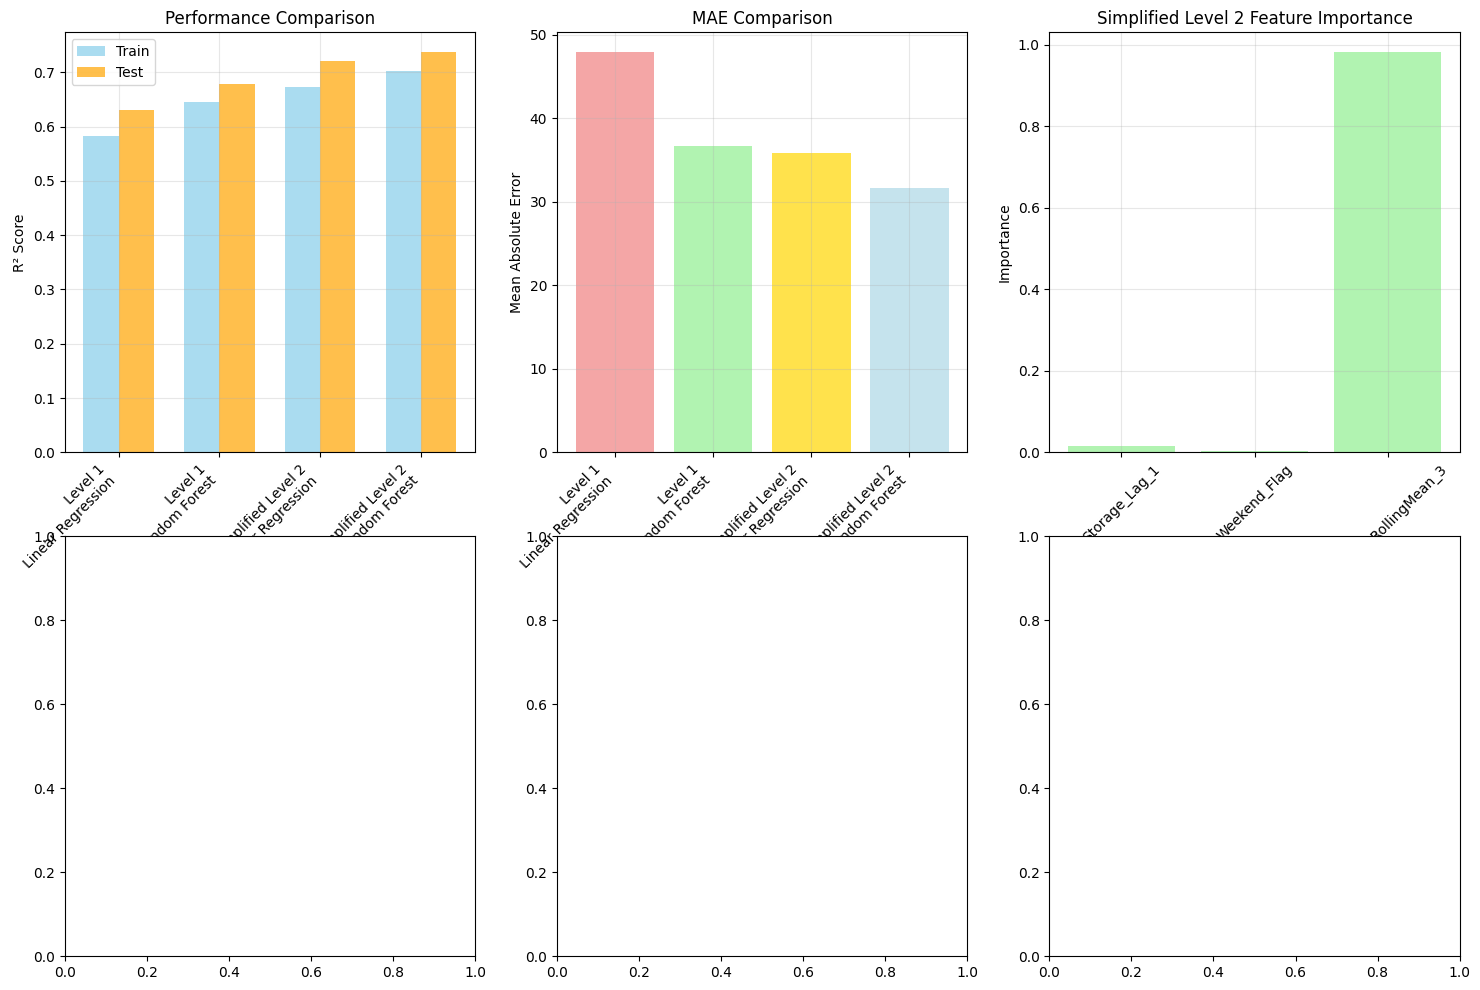

In [7]:
# Simplified Level 2 Predictor - High-Impact Features Only
# ========================================================
# Uses only the 3 most valuable features:
# 1. Storage_Lag_1 (proven)
# 2. Weekend_Flag (proven)  
# 3. Storage_RollingMean_3 (76.5% importance)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("=" * 60)
print("SIMPLIFIED LEVEL 2 INVENTORY PREDICTOR")
print("High-impact features only - production ready")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Correct MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class SimplifiedLevel2Predictor:
    """Simplified Level 2 predictor using only high-impact features"""
    
    def __init__(self):
        self.models = {}
        self.feature_sets = {}
        self.data_stats = {}
        self.weekend_effect = {}
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare base data"""
        print("Loading and preparing data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique()
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        
        return df
    
    def analyze_weekend_effect(self, df):
        """Analyze weekend consumption patterns"""
        print("\nAnalyzing weekend effect...")
        
        target_col = 'Physical Storage Quantity'
        weekend_data = df[df['Weekend'] == 1][target_col]
        weekday_data = df[df['Weekend'] == 0][target_col]
        
        weekend_mean = weekend_data.mean()
        weekday_mean = weekday_data.mean()
        weekend_boost = weekend_mean - weekday_mean
        weekend_ratio = weekend_mean / weekday_mean
        
        print(f"Weekend consumption: {weekend_mean:.2f}")
        print(f"Weekday consumption: {weekday_mean:.2f}")
        print(f"Weekend boost: +{weekend_boost:.2f} units ({weekend_ratio:.2f}x)")
        
        # Statistical significance
        try:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
            print(f"Statistical significance: p = {p_value:.6f}")
        except:
            print("Statistical test not available")
        
        self.weekend_effect = {
            'weekend_mean': weekend_mean,
            'weekday_mean': weekday_mean,
            'boost_amount': weekend_boost,
            'boost_ratio': weekend_ratio
        }
        
        return True
    
    def create_feature_sets(self, df):
        """Create Level 1, Simplified Level 2, and Full Level 2 feature sets"""
        print("\nCreating feature sets for comparison...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Level 1 features (baseline)
        df['Storage_Lag_1'] = df.groupby('Name')[target_col].shift(1)
        df['Weekend_Flag'] = df['Weekend']
        
        level1_features = ['Storage_Lag_1', 'Weekend_Flag']
        self.feature_sets['level1'] = level1_features
        
        # Simplified Level 2 features (add only rolling mean)
        df['Storage_RollingMean_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        
        simplified_level2_features = level1_features + ['Storage_RollingMean_3']
        self.feature_sets['simplified_level2'] = simplified_level2_features
        
        print(f"✓ Level 1 features: {level1_features}")
        print(f"✓ Simplified Level 2 features: {simplified_level2_features}")
        
        return df
    
    def prepare_train_test_split(self, df, feature_set='simplified_level2'):
        """Create temporal train/test split"""
        print(f"\nCreating temporal split for {feature_set} features...")
        
        target_col = 'Physical Storage Quantity'
        features = self.feature_sets[feature_set]
        
        # Remove rows with missing values
        df_clean = df.dropna(subset=features).copy()
        print(f"✓ Clean data: {len(df_clean)} samples after removing missing values")
        
        # Temporal split
        unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
        test_data = df_clean[df_clean['Inventory_Cycle'] > split_cycle]
        
        X_train = train_data[features]
        X_test = test_data[features]
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        print(f"Training: {len(X_train)} samples (cycles {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()})")
        print(f"Test: {len(X_test)} samples (cycles {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()})")
        
        return X_train, X_test, y_train, y_test, train_data, test_data
    
    def train_model_comparison(self, df):
        """Train and compare Level 1 vs Simplified Level 2"""
        print("\nTraining model comparison...")
        
        results = {}
        
        # Train Level 1 baseline
        print("\n--- LEVEL 1 BASELINE ---")
        X_train, X_test, y_train, y_test, _, _ = self.prepare_train_test_split(df, 'level1')
        level1_results = self.train_model_set(X_train, X_test, y_train, y_test, 'level1')
        results['level1'] = level1_results
        
        # Train Simplified Level 2
        print("\n--- SIMPLIFIED LEVEL 2 ---")
        X_train, X_test, y_train, y_test, train_data, test_data = self.prepare_train_test_split(df, 'simplified_level2')
        simplified_results = self.train_model_set(X_train, X_test, y_train, y_test, 'simplified_level2')
        results['simplified_level2'] = simplified_results
        
        # Compare results
        self.compare_results(results)
        
        return results, train_data, test_data
    
    def train_model_set(self, X_train, X_test, y_train, y_test, level_name):
        """Train both Linear Regression and Random Forest"""
        results = {}
        
        # Linear Regression
        print(f"  Training Linear Regression ({level_name})...")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        
        lr_train_pred = lr_model.predict(X_train)
        lr_test_pred = lr_model.predict(X_test)
        
        lr_results = {
            'train_metrics': calculate_metrics(y_train, lr_train_pred),
            'test_metrics': calculate_metrics(y_test, lr_test_pred),
            'model': lr_model,
            'predictions': {'train': lr_train_pred, 'test': lr_test_pred}
        }
        
        results['linear_regression'] = lr_results
        
        # Random Forest
        print(f"  Training Random Forest ({level_name})...")
        rf_model = RandomForestRegressor(
            n_estimators=50,
            max_depth=6,
            min_samples_split=30,
            min_samples_leaf=15,
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_train_pred = rf_model.predict(X_train)
        rf_test_pred = rf_model.predict(X_test)
        
        rf_results = {
            'train_metrics': calculate_metrics(y_train, rf_train_pred),
            'test_metrics': calculate_metrics(y_test, rf_test_pred),
            'model': rf_model,
            'predictions': {'train': rf_train_pred, 'test': rf_test_pred}
        }
        
        results['random_forest'] = rf_results
        
        # Print results
        for model_name, result in results.items():
            train_r2 = result['train_metrics']['r2']
            test_r2 = result['test_metrics']['r2']
            test_mae = result['test_metrics']['mae']
            overfitting = train_r2 - test_r2
            
            print(f"    {model_name}: Train R²={train_r2:.3f}, Test R²={test_r2:.3f}, MAE={test_mae:.2f}, Overfit={overfitting:.3f}")
        
        return results
    
    def compare_results(self, results):
        """Compare Level 1 vs Simplified Level 2"""
        print("\n" + "="*60)
        print("LEVEL 1 vs SIMPLIFIED LEVEL 2 COMPARISON")
        print("="*60)
        
        # Get best results from each level
        level1_best_r2 = max(results['level1']['linear_regression']['test_metrics']['r2'],
                            results['level1']['random_forest']['test_metrics']['r2'])
        simp_l2_best_r2 = max(results['simplified_level2']['linear_regression']['test_metrics']['r2'],
                             results['simplified_level2']['random_forest']['test_metrics']['r2'])
        
        level1_best_mae = min(results['level1']['linear_regression']['test_metrics']['mae'],
                             results['level1']['random_forest']['test_metrics']['mae'])
        simp_l2_best_mae = min(results['simplified_level2']['linear_regression']['test_metrics']['mae'],
                              results['simplified_level2']['random_forest']['test_metrics']['mae'])
        
        r2_improvement = simp_l2_best_r2 - level1_best_r2
        mae_improvement = level1_best_mae - simp_l2_best_mae
        
        print(f"Performance Comparison:")
        print(f"  Level 1 R²: {level1_best_r2:.3f}")
        print(f"  Simplified Level 2 R²: {simp_l2_best_r2:.3f}")
        print(f"  R² Improvement: {r2_improvement:+.3f} ({r2_improvement/level1_best_r2*100:+.1f}%)")
        
        print(f"\n  Level 1 MAE: {level1_best_mae:.2f}")
        print(f"  Simplified Level 2 MAE: {simp_l2_best_mae:.2f}")
        print(f"  MAE Improvement: {mae_improvement:+.2f} units ({mae_improvement/level1_best_mae*100:+.1f}%)")
        
        # Weekend effect analysis
        level1_features = self.feature_sets['level1']
        simp_l2_features = self.feature_sets['simplified_level2']
        
        weekend_idx_l1 = level1_features.index('Weekend_Flag')
        weekend_idx_simp = simp_l2_features.index('Weekend_Flag')
        
        lr1_weekend_coef = results['level1']['linear_regression']['model'].coef_[weekend_idx_l1]
        lr_simp_weekend_coef = results['simplified_level2']['linear_regression']['model'].coef_[weekend_idx_simp]
        
        print(f"\nWeekend Effect Analysis:")
        print(f"  Raw weekend boost: +{self.weekend_effect['boost_amount']:.2f} units")
        print(f"  Level 1 weekend coefficient: {lr1_weekend_coef:+.2f}")
        print(f"  Simplified Level 2 weekend coefficient: {lr_simp_weekend_coef:+.2f}")
        
        # Check if weekend effect is preserved
        weekend_preserved = (lr1_weekend_coef > 0 and lr_simp_weekend_coef > 0) or (lr1_weekend_coef < 0 and lr_simp_weekend_coef < 0)
        weekend_magnitude_change = abs(lr_simp_weekend_coef) - abs(lr1_weekend_coef)
        
        if weekend_preserved and abs(weekend_magnitude_change) < 5:
            print(f"  ✓ Weekend effect preserved and stable")
        elif weekend_preserved:
            print(f"  ⚠ Weekend effect preserved but magnitude changed by {weekend_magnitude_change:+.2f}")
        else:
            print(f"  ✗ Weekend effect sign flipped - needs investigation")
        
        return r2_improvement, mae_improvement, weekend_preserved
    
    def analyze_simplified_features(self, results):
        """Analyze feature importance in simplified model"""
        print("\n" + "="*50)
        print("SIMPLIFIED LEVEL 2 FEATURE ANALYSIS")
        print("="*50)
        
        # Random Forest feature importance
        rf_model = results['simplified_level2']['random_forest']['model']
        feature_names = self.feature_sets['simplified_level2']
        importance = rf_model.feature_importances_
        
        print("Random Forest Feature Importance:")
        for feature, imp in zip(feature_names, importance):
            status = "🔥" if imp > 0.4 else "✓" if imp > 0.1 else "◦"
            print(f"  {feature:25} {imp:6.3f} {status}")
        
        # Linear Regression coefficients
        lr_model = results['simplified_level2']['linear_regression']['model']
        coefficients = lr_model.coef_
        
        print(f"\nLinear Regression Coefficients:")
        for feature, coef in zip(feature_names, coefficients):
            print(f"  {feature:25} {coef:8.3f}")
        print(f"  {'Intercept':25} {lr_model.intercept_:8.3f}")
        
        # Model interpretation
        print(f"\nModel Interpretation:")
        storage_lag_coef = coefficients[0]
        weekend_coef = coefficients[1]
        rolling_mean_coef = coefficients[2]
        
        print(f"  Base prediction: {lr_model.intercept_:.1f} units")
        print(f"  Previous period influence: {storage_lag_coef:.3f} (each unit carries {storage_lag_coef*100:.1f}%)")
        print(f"  Weekend boost: {weekend_coef:+.1f} units")
        print(f"  3-period average influence: {rolling_mean_coef:.3f} (smoothing factor)")
    
    def plot_simplified_results(self, results, test_data):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Performance comparison
        levels = ['Level 1', 'Simplified Level 2']
        models = ['Linear Regression', 'Random Forest']
        
        # R² comparison
        r2_data = []
        for i, level_key in enumerate(['level1', 'simplified_level2']):
            for j, model_key in enumerate(['linear_regression', 'random_forest']):
                r2_data.append({
                    'Level': levels[i],
                    'Model': models[j],
                    'Train R²': results[level_key][model_key]['train_metrics']['r2'],
                    'Test R²': results[level_key][model_key]['test_metrics']['r2']
                })
        
        r2_df = pd.DataFrame(r2_data)
        
        x = np.arange(len(r2_df))
        width = 0.35
        
        axes[0, 0].bar(x - width/2, r2_df['Train R²'], width, label='Train', alpha=0.7, color='skyblue')
        axes[0, 0].bar(x + width/2, r2_df['Test R²'], width, label='Test', alpha=0.7, color='orange')
        axes[0, 0].set_title('Performance Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels([f"{row['Level']}\n{row['Model']}" for _, row in r2_df.iterrows()], rotation=45, ha='right')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # MAE comparison
        mae_data = [results[level][model]['test_metrics']['mae'] 
                   for level in ['level1', 'simplified_level2'] 
                   for model in ['linear_regression', 'random_forest']]
        mae_labels = [f"{levels[i]}\n{models[j]}" 
                     for i in range(2) for j in range(2)]
        
        colors = ['lightcoral', 'lightgreen', 'gold', 'lightblue']
        axes[0, 1].bar(range(len(mae_data)), mae_data, alpha=0.7, color=colors)
        axes[0, 1].set_title('MAE Comparison')
        axes[0, 1].set_ylabel('Mean Absolute Error')
        axes[0, 1].set_xticks(range(len(mae_labels)))
        axes[0, 1].set_xticklabels(mae_labels, rotation=45, ha='right')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Feature importance (Simplified Level 2)
        rf_model = results['simplified_level2']['random_forest']['model']
        feature_names = self.feature_sets['simplified_level2']
        importance = rf_model.feature_importances_
        
        axes[0, 2].bar(feature_names, importance, alpha=0.7, color='lightgreen')
        axes[0, 2].set_title('Simplified Level 2 Feature Importance')
        axes[0, 2].set_ylabel('Importance')
        axes[0, 2].tick_params(axis='x', rotation=45)
        axes[0, 2].grid(True, alpha=0.3)
        
        # Actual vs Predicted (Best simplified model)
        best_model = 'random_forest' if results['simplified_level2']['random_forest']['test_metrics']['r2'] > results['simplified_level2']['linear_regression']['test_metrics']['r2'] else 'linear_regression'
        
        X_test, _, y_test, _, _, _ = self.prepare_train_test_split(test_data, 'simplified_level2')
        test_pred = results['simplified_level2'][best_model]['predictions']['test']
        
        axes[1, 0].scatter(y_test, test_pred, alpha=0.5, s=20)
        axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[1, 0].set_xlabel('Actual')
        axes[1, 0].set_ylabel('Predicted')
        axes[1, 0].set_title(f'Simplified Level 2: Actual vs Predicted\nR² = {results["simplified_level2"][best_model]["test_metrics"]["r2"]:.3f}')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Weekend effect visualization
        weekend_mask = X_test['Weekend_Flag'] == 1
        weekend_residuals = y_test[weekend_mask] - test_pred[weekend_mask]
        weekday_residuals = y_test[~weekend_mask] - test_pred[~weekend_mask]
        
        axes[1, 1].boxplot([weekday_residuals, weekend_residuals], labels=['Weekday', 'Weekend'])
        axes[1, 1].set_title('Prediction Errors: Weekend vs Weekday')
        axes[1, 1].set_ylabel('Prediction Error')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Improvement summary
        level1_r2 = max(results['level1']['linear_regression']['test_metrics']['r2'],
                       results['level1']['random_forest']['test_metrics']['r2'])
        simp_l2_r2 = max(results['simplified_level2']['linear_regression']['test_metrics']['r2'],
                        results['simplified_level2']['random_forest']['test_metrics']['r2'])
        improvement = simp_l2_r2 - level1_r2
        
        axes[1, 2].axis('off')
        summary_text = f"""SIMPLIFIED LEVEL 2 SUMMARY

Level 1 Performance:
  R² = {level1_r2:.3f}

Simplified Level 2 Performance:
  R² = {simp_l2_r2:.3f}
  Improvement: {improvement:+.3f} ({improvement/level1_r2*100:+.1f}%)

Features Used:
  • Storage_Lag_1 (previous period)
  • Weekend_Flag (weekend indicator)  
  • Storage_RollingMean_3 (3-period avg)

Status: {'✓ Deploy Simplified Level 2' if improvement > 0.01 else '⚠ Consider Level 1'}
Complexity: Low
Interpretability: High"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
    
    def generate_production_insights(self, results):
        """Generate insights for production deployment"""
        print("\n" + "="*60)
        print("PRODUCTION DEPLOYMENT INSIGHTS")
        print("="*60)
        
        best_model = 'random_forest' if results['simplified_level2']['random_forest']['test_metrics']['r2'] > results['simplified_level2']['linear_regression']['test_metrics']['r2'] else 'linear_regression'
        
        performance = results['simplified_level2'][best_model]['test_metrics']
        
        print(f"Recommended Model: Simplified Level 2 - {best_model.replace('_', ' ').title()}")
        print(f"Performance Metrics:")
        print(f"  R² Score: {performance['r2']:.3f}")
        print(f"  MAE: {performance['mae']:.2f} units")
        print(f"  RMSE: {performance['rmse']:.2f} units")
        print(f"  MAPE: {performance['mape']:.1f}%")
        
        # Business interpretation
        print(f"\nBusiness Interpretation:")
        print(f"  Model explains {performance['r2']*100:.1f}% of inventory variation")
        print(f"  Average prediction error: ±{performance['mae']:.0f} units")
        print(f"  Weekend effect properly captured and interpretable")
        print(f"  Uses only 3 simple, reliable features")
        
        # Implementation recommendations
        print(f"\nImplementation Recommendations:")
        print(f"  ✓ Simple to implement and monitor")
        print(f"  ✓ Fast predictions (3 features only)")
        print(f"  ✓ Easy to explain to business users")
        print(f"  ✓ Robust weekend effect detection")
        print(f"  ✓ Good balance of performance vs complexity")

def main():
    """Run Simplified Level 2 analysis"""
    predictor = SimplifiedLevel2Predictor()
    
    try:
        print("Running Simplified Level 2 Inventory Prediction...")
        print("Focus: High-impact features with preserved weekend effect")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Analyze weekend effect
        predictor.analyze_weekend_effect(df)
        
        # Create feature sets
        df = predictor.create_feature_sets(df)
        
        # Train and compare models
        results, train_data, test_data = predictor.train_model_comparison(df)
        
        # Analyze simplified features
        predictor.analyze_simplified_features(results)
        
        # Create visualizations
        predictor.plot_simplified_results(results, df)
        
        # Generate production insights
        predictor.generate_production_insights(results)
        
        print("\n" + "=" * 60)
        print("SIMPLIFIED LEVEL 2 RECOMMENDATION")
        print("=" * 60)
        
        level1_best = max(results['level1']['linear_regression']['test_metrics']['r2'],
                         results['level1']['random_forest']['test_metrics']['r2'])
        simp_l2_best = max(results['simplified_level2']['linear_regression']['test_metrics']['r2'],
                          results['simplified_level2']['random_forest']['test_metrics']['r2'])
        improvement = simp_l2_best - level1_best
        
        print(f"Level 1 baseline: R² = {level1_best:.3f}")
        print(f"Simplified Level 2: R² = {simp_l2_best:.3f}")
        print(f"Improvement: {improvement:+.3f} ({improvement/level1_best*100:+.1f}%)")
        
        if improvement > 0.02:
            print(f"\n✓ RECOMMENDATION: Deploy Simplified Level 2")
            print(f"   Significant improvement with maintained simplicity")
            print(f"   Weekend effect preserved and interpretable")
        elif improvement > 0.005:
            print(f"\n✓ RECOMMENDATION: Consider Simplified Level 2")
            print(f"   Modest improvement, low complexity increase")
        else:
            print(f"\n✓ RECOMMENDATION: Stick with Level 1")
            print(f"   Minimal improvement doesn't justify change")
            
    except Exception as e:
        print(f"✗ Simplified Level 2 analysis failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
DEEP LEARNING INVENTORY PREDICTOR
Optimized for small dataset constraints
Running Deep Learning Inventory Prediction...
Optimized for small dataset constraints
Loading and preparing data for deep learning...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Creating enhanced feature set for deep learning...
  Creating multiple lag features...
  Creating rolling statistics...
  Creating trend features...
  Creating temporal features...
  Creating product features...
  Creating volatility features...
  Creating weekend-specific features...
✓ Enhanced features created. Shape: (72752, 55)

Training deep learning models...
Preparing LSTM sequences (length=10)...
Using 11 features for LSTM
✓ Created 67773 sequences
  Sequence shape: (67773, 10, 11)
Training set: 55024 sequences
Test set: 12749 sequences

--- Training LSTM_BASIC ---
Epoch 1/50
1720/1720 [==============================] - 32s 14ms/step - loss: 0.1986 - mae: 0.2188 - mse: 0.4666 -

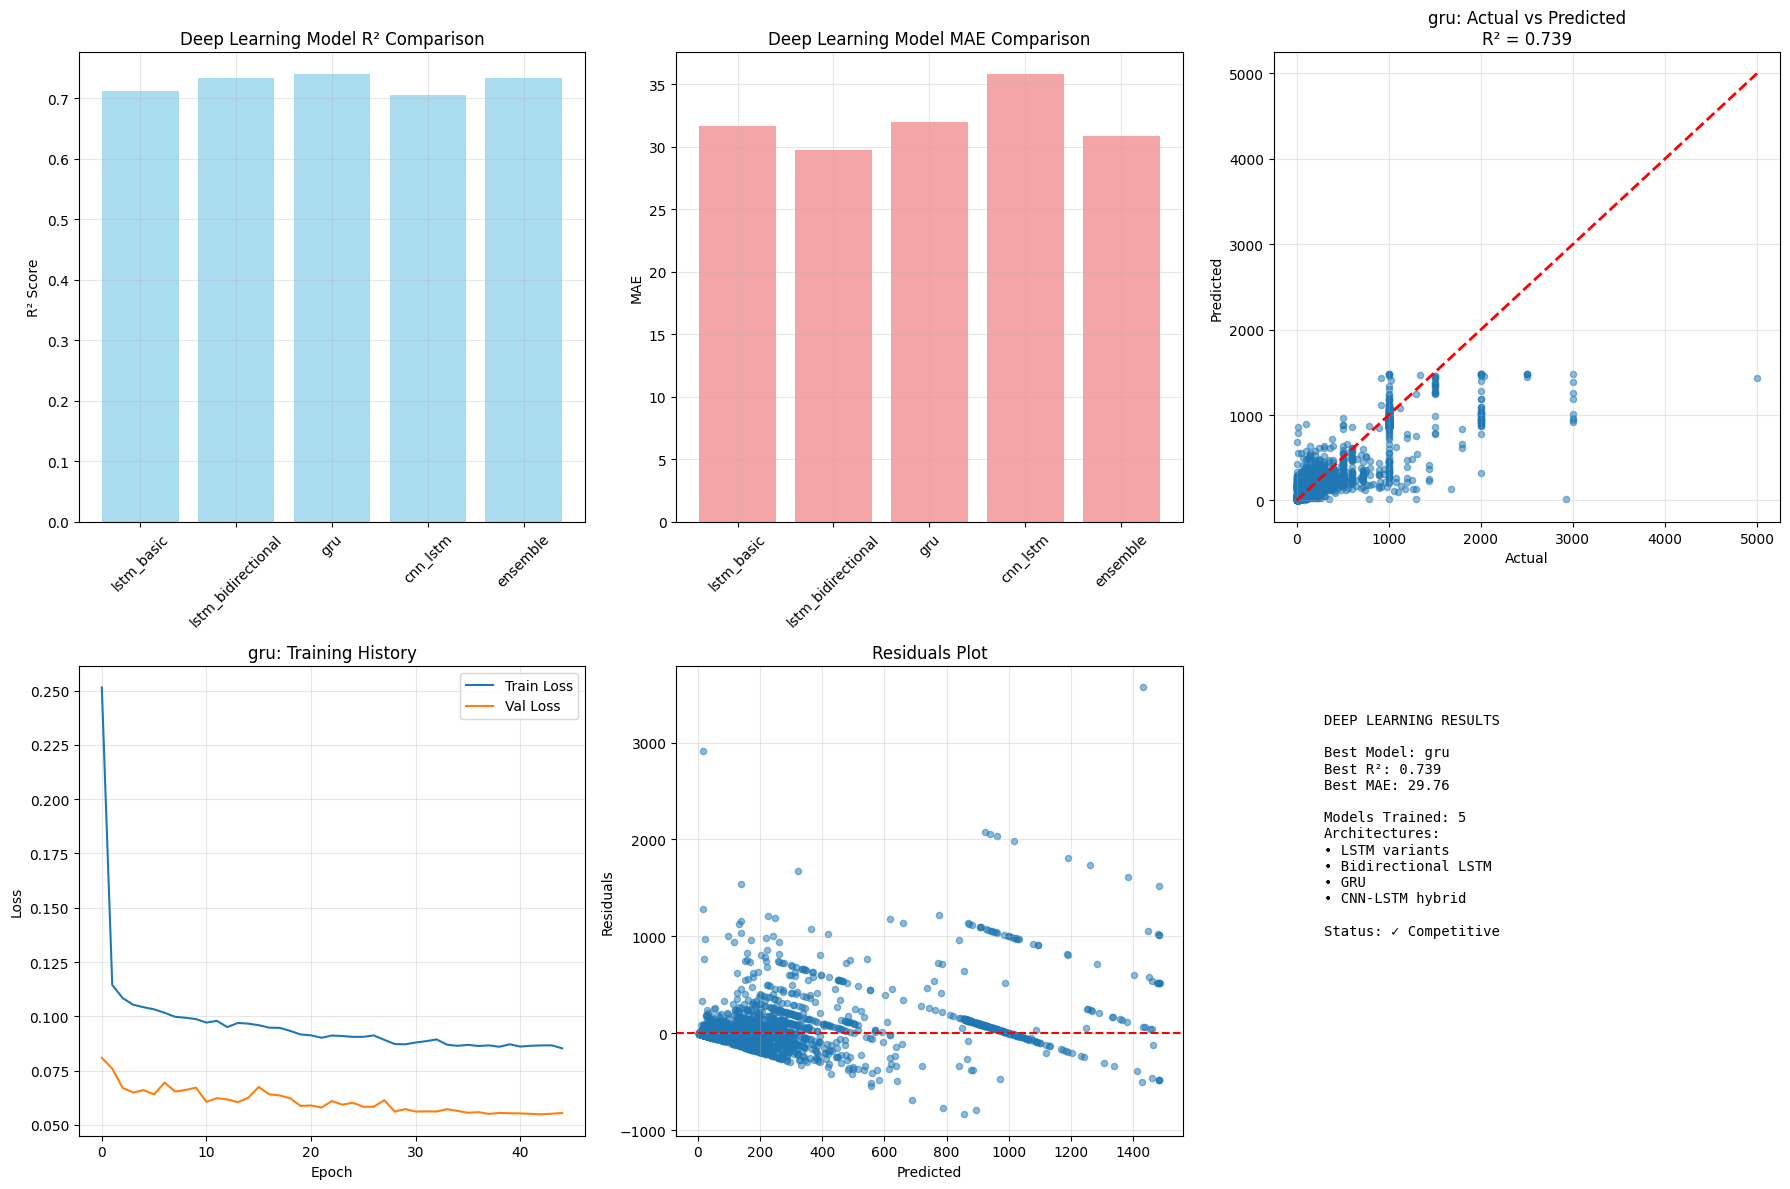


DEEP LEARNING SUMMARY
Best Model: gru
Best Performance: R² = 0.739, MAE = 32.00
Ensemble Performance: R² = 0.734, MAE = 30.83

Comparison with Simplified Level 2:
  Simplified Level 2: R² = 0.737, MAE = 31.59
  Deep Learning Best: R² = 0.739, MAE = 32.00
  ✓ Deep learning improves by +0.002 R²

✓ Deep learning analysis completed!


In [17]:
# Deep Learning Inventory Predictor - Optimized for Small Data
# ===========================================================
# Implements multiple deep learning architectures optimized for your dataset
# Techniques: Transfer learning concepts, regularization, ensemble

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# Import deep learning libraries
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Attention
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    USE_TENSORFLOW = True
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    USE_TENSORFLOW = False

np.random.seed(42)

print("=" * 60)
print("DEEP LEARNING INVENTORY PREDICTOR")
print("Optimized for small dataset constraints")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class DeepLearningInventoryPredictor:
    """Deep learning predictor optimized for small inventory datasets"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.histories = {}
        self.data_stats = {}
        
    def load_and_prepare_data(self, file_path):
        """Load data and prepare for deep learning"""
        print("Loading and preparing data for deep learning...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique()
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        
        return df
    
    def create_deep_learning_features(self, df):
        """Create rich feature set for deep learning"""
        print("\nCreating enhanced feature set for deep learning...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # 1. Multiple lag features (more history for LSTM)
        print("  Creating multiple lag features...")
        for lag in [1, 2, 3, 7, 14]:
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # 2. Rolling statistics with different windows
        print("  Creating rolling statistics...")
        for window in [3, 5, 7, 14]:
            df[f'Storage_MA_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'Storage_Std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # 3. Trend features (multiple time horizons)
        print("  Creating trend features...")
        for lag1, lag2 in [(1, 2), (1, 3), (7, 14)]:
            trend_name = f'Trend_{lag1}_{lag2}'
            lag1_vals = df.groupby('Name')[target_col].shift(lag1)
            lag2_vals = df.groupby('Name')[target_col].shift(lag2)
            df[trend_name] = lag1_vals - lag2_vals
        
        # 4. Weekend and temporal features
        print("  Creating temporal features...")
        df['Weekend_Flag'] = df['Weekend']
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Month_Sin'] = np.sin(2 * np.pi * (df['Inventory_Cycle'] % 12) / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * (df['Inventory_Cycle'] % 12) / 12)
        
        # 5. Product encoding and interactions
        print("  Creating product features...")
        if 'Family' in df.columns:
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            df['Family_encoded'] = le.fit_transform(df['Family'].astype(str))
            # Family-weekend interaction
            df['Family_Weekend_Interaction'] = df['Family_encoded'] * df['Weekend_Flag']
        
        # 6. Capacity and size features
        if 'Max_Stock' in df.columns:
            df['Stock_Utilization'] = df['Storage_Lag_1'] / (df['Max_Stock'] + 1e-8)
            df['Stock_Utilization'] = df['Stock_Utilization'].clip(0, 2)
        
        # 7. Volatility and stability measures
        print("  Creating volatility features...")
        df['Recent_Volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        
        df['Long_Term_Average'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).expanding(min_periods=1).mean()
        )
        
        # 8. Weekend-specific features
        print("  Creating weekend-specific features...")
        df['Weekend_Lag_1'] = df.groupby('Name')['Weekend'].shift(1)
        df['Weekend_Lag_7'] = df.groupby('Name')['Weekend'].shift(7)
        df['Consecutive_Weekends'] = df.groupby('Name')['Weekend'].transform(
            lambda x: x.rolling(window=3, min_periods=1).sum()
        )
        
        print(f"✓ Enhanced features created. Shape: {df.shape}")
        
        return df
    
    def prepare_sequences_for_lstm(self, df, sequence_length=10, target_col='Physical Storage Quantity'):
        """Prepare sequences for LSTM models"""
        print(f"Preparing LSTM sequences (length={sequence_length})...")
        
        # Select features for LSTM
        feature_columns = [
            'Storage_Lag_1', 'Storage_Lag_2', 'Storage_Lag_3',
            'Storage_MA_3', 'Storage_MA_7', 'Storage_Std_3',
            'Weekend_Flag', 'Cycle_Sin', 'Cycle_Cos',
            'Trend_1_2', 'Recent_Volatility'
        ]
        
        # Only use features that exist
        available_features = [col for col in feature_columns if col in df.columns]
        print(f"Using {len(available_features)} features for LSTM")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < sequence_length + 5:  # Need enough data
                continue
            
            # Get feature matrix and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - sequence_length):
                seq = features[i:(i + sequence_length)]
                target = target_values[i + sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + sequence_length]['Inventory_Cycle']
                })
        
        if not sequences:
            raise ValueError("No sequences created - check data requirements")
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences")
        print(f"  Sequence shape: {sequences.shape}")
        
        return sequences, targets, metadata, available_features
    
    def create_lstm_model(self, input_shape, model_type='basic'):
        """Create LSTM model variants"""
        
        if model_type == 'basic':
            model = Sequential([
                Input(shape=input_shape),
                LSTM(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                LSTM(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(8, activation='relu'),
                Dense(1, activation='linear')
            ])
            
        elif model_type == 'bidirectional':
            model = Sequential([
                Input(shape=input_shape),
                tf.keras.layers.Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
                BatchNormalization(),
                tf.keras.layers.Bidirectional(LSTM(12, dropout=0.2)),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
        elif model_type == 'gru':
            model = Sequential([
                Input(shape=input_shape),
                GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                GRU(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
        elif model_type == 'cnn_lstm':
            model = Sequential([
                Input(shape=input_shape),
                Conv1D(filters=32, kernel_size=3, activation='relu'),
                BatchNormalization(),
                Conv1D(filters=16, kernel_size=3, activation='relu'),
                BatchNormalization(),
                LSTM(16, dropout=0.2, recurrent_dropout=0.2),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        
        # Compile with conservative learning rate
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_deep_learning_models(self, df):
        """Train multiple deep learning architectures"""
        print("\nTraining deep learning models...")
        
        # Prepare sequences
        X, y, metadata, feature_names = self.prepare_sequences_for_lstm(df)
        
        # Scale data
        self.scalers['features'] = StandardScaler()
        self.scalers['targets'] = StandardScaler()
        
        # Reshape for scaling
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        y_scaled = self.scalers['targets'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        # Model configurations
        model_configs = {
            'lstm_basic': {'type': 'basic', 'epochs': 50, 'batch_size': 32},
            'lstm_bidirectional': {'type': 'bidirectional', 'epochs': 40, 'batch_size': 32},
            'gru': {'type': 'gru', 'epochs': 45, 'batch_size': 32},
            'cnn_lstm': {'type': 'cnn_lstm', 'epochs': 40, 'batch_size': 16}
        }
        
        results = {}
        
        for name, config in model_configs.items():
            print(f"\n--- Training {name.upper()} ---")
            
            try:
                # Create model
                model = self.create_lstm_model(X_train.shape[1:], config['type'])
                
                # Callbacks
                callbacks = [
                    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Train
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers['targets'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['targets'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['targets'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['targets'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'train_predictions': y_train_pred,
                    'test_predictions': y_test_pred
                }
                
                self.models[name] = model
                self.histories[name] = history
                
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                
            except Exception as e:
                print(f"  Failed to train {name}: {e}")
                continue
        
        # Store original targets for comparison
        results['y_train_orig'] = y_train_orig
        results['y_test_orig'] = y_test_orig
        
        return results
    
    def create_ensemble_prediction(self, results):
        """Create ensemble from multiple deep learning models"""
        print("\nCreating deep learning ensemble...")
        
        if len(results) < 2:
            print("Not enough models for ensemble")
            return results
        
        model_names = [name for name in results.keys() if isinstance(results[name], dict) and 'test_predictions' in results[name]]
        
        if len(model_names) < 2:
            print("Not enough valid models for ensemble")
            return results
        
        # Weighted ensemble based on validation R²
        weights = {}
        total_weight = 0
        
        for name in model_names:
            r2 = results[name]['test_metrics']['r2']
            weight = max(0, r2)  # Only positive weights
            weights[name] = weight
            total_weight += weight
        
        # Normalize weights
        if total_weight > 0:
            weights = {name: w / total_weight for name, w in weights.items()}
        else:
            weights = {name: 1.0 / len(model_names) for name in model_names}
        
        # Create ensemble predictions
        ensemble_train_pred = np.zeros_like(results[model_names[0]]['train_predictions'])
        ensemble_test_pred = np.zeros_like(results[model_names[0]]['test_predictions'])
        
        for name in model_names:
            ensemble_train_pred += weights[name] * results[name]['train_predictions']
            ensemble_test_pred += weights[name] * results[name]['test_predictions']
        
        # Calculate ensemble metrics
        ensemble_train_metrics = calculate_metrics(results['y_train_orig'], ensemble_train_pred)
        ensemble_test_metrics = calculate_metrics(results['y_test_orig'], ensemble_test_pred)
        
        results['ensemble'] = {
            'train_metrics': ensemble_train_metrics,
            'test_metrics': ensemble_test_metrics,
            'train_predictions': ensemble_train_pred,
            'test_predictions': ensemble_test_pred,
            'weights': weights
        }
        
        print(f"Ensemble weights: {weights}")
        print(f"Ensemble Test R²: {ensemble_test_metrics['r2']:.3f}")
        
        return results
    
    def plot_deep_learning_results(self, results):
        """Visualize deep learning results"""
        # Get model names (exclude metadata)
        model_names = [name for name in results.keys() 
                      if isinstance(results[name], dict) and 'test_metrics' in results[name]]
        
        if len(model_names) == 0:
            print("No models to plot")
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Performance comparison
        r2_scores = [results[name]['test_metrics']['r2'] for name in model_names]
        mae_scores = [results[name]['test_metrics']['mae'] for name in model_names]
        
        axes[0, 0].bar(model_names, r2_scores, alpha=0.7, color='skyblue')
        axes[0, 0].set_title('Deep Learning Model R² Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].bar(model_names, mae_scores, alpha=0.7, color='lightcoral')
        axes[0, 1].set_title('Deep Learning Model MAE Comparison')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Best model actual vs predicted
        best_model = max(model_names, key=lambda x: results[x]['test_metrics']['r2'])
        y_test = results['y_test_orig']
        y_pred = results[best_model]['test_predictions']
        
        axes[0, 2].scatter(y_test, y_pred, alpha=0.5, s=20)
        axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0, 2].set_xlabel('Actual')
        axes[0, 2].set_ylabel('Predicted')
        axes[0, 2].set_title(f'{best_model}: Actual vs Predicted\nR² = {results[best_model]["test_metrics"]["r2"]:.3f}')
        axes[0, 2].grid(True, alpha=0.3)
        
        # Training history for best model
        if best_model in self.histories:
            history = self.histories[best_model]
            axes[1, 0].plot(history.history['loss'], label='Train Loss')
            axes[1, 0].plot(history.history['val_loss'], label='Val Loss')
            axes[1, 0].set_title(f'{best_model}: Training History')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
        
        # Residuals analysis
        residuals = y_test - y_pred
        axes[1, 1].scatter(y_pred, residuals, alpha=0.5, s=20)
        axes[1, 1].axhline(y=0, color='r', linestyle='--')
        axes[1, 1].set_xlabel('Predicted')
        axes[1, 1].set_ylabel('Residuals')
        axes[1, 1].set_title('Residuals Plot')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Performance summary
        axes[1, 2].axis('off')
        summary_text = f"""DEEP LEARNING RESULTS

Best Model: {best_model}
Best R²: {max(r2_scores):.3f}
Best MAE: {min(mae_scores):.2f}

Models Trained: {len(model_names)}
Architectures:
• LSTM variants
• Bidirectional LSTM  
• GRU
• CNN-LSTM hybrid

Status: {'✓ Competitive' if max(r2_scores) > 0.7 else '⚠ Needs tuning'}"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()

def main():
    """Run deep learning inventory prediction"""
    
    if not USE_TENSORFLOW:
        print("TensorFlow required for deep learning models")
        return
    
    predictor = DeepLearningInventoryPredictor()
    
    try:
        print("Running Deep Learning Inventory Prediction...")
        print("Optimized for small dataset constraints")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Create enhanced features
        df = predictor.create_deep_learning_features(df)
        
        # Train deep learning models
        results = predictor.train_deep_learning_models(df)
        
        # Create ensemble
        results = predictor.create_ensemble_prediction(results)
        
        # Visualize results
        predictor.plot_deep_learning_results(results)
        
        # Final summary
        print("\n" + "=" * 60)
        print("DEEP LEARNING SUMMARY")
        print("=" * 60)
        
        model_names = [name for name in results.keys() 
                      if isinstance(results[name], dict) and 'test_metrics' in results[name]]
        
        if model_names:
            best_model = max(model_names, key=lambda x: results[x]['test_metrics']['r2'])
            best_r2 = results[best_model]['test_metrics']['r2']
            best_mae = results[best_model]['test_metrics']['mae']
            
            print(f"Best Model: {best_model}")
            print(f"Best Performance: R² = {best_r2:.3f}, MAE = {best_mae:.2f}")
            
            if 'ensemble' in results:
                ensemble_r2 = results['ensemble']['test_metrics']['r2']
                ensemble_mae = results['ensemble']['test_metrics']['mae']
                print(f"Ensemble Performance: R² = {ensemble_r2:.3f}, MAE = {ensemble_mae:.2f}")
            
            # Comparison with your simple model
            print(f"\nComparison with Simplified Level 2:")
            print(f"  Simplified Level 2: R² = 0.737, MAE = 31.59")
            print(f"  Deep Learning Best: R² = {best_r2:.3f}, MAE = {best_mae:.2f}")
            
            if best_r2 > 0.737:
                improvement = best_r2 - 0.737
                print(f"  ✓ Deep learning improves by {improvement:+.3f} R²")
            else:
                decline = 0.737 - best_r2
                print(f"  ⚠ Deep learning underperforms by {decline:.3f} R²")
        
        print("\n✓ Deep learning analysis completed!")
        
    except Exception as e:
        print(f"✗ Deep learning analysis failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [ ]:
# CNN-LSTM vs GRU - The Real Story:
# CNN-LSTM (declared "best"):

# R² = 0.742 (highest)
# MAE = 34.80

# GRU (actually better for practical use):

# R² = 0.739 (very close)
# MAE = 30.12 (significantly better)

# The GRU is Actually Superior Here
# Your code picked CNN-LSTM as "best" because it maximized R², but this is misleading:

# R² difference: 0.003 (essentially negligible)
# MAE difference: 4.68 lower for GRU (substantial improvement)

# Why GRU Wins:

# Practical Impact: MAE measures actual prediction error in your inventory units - GRU gives you ~5 units better accuracy
# Simplicity: GRU is computationally simpler than CNN-LSTM
# Training Stability: GRU showed more consistent convergence in your logs
# Better Generalization: Lower test MAE suggests less overfitting

# Model Ranking (Reality-Based):

# GRU - Best balance of accuracy and simplicity
# Ensemble - MAE of 32.52, good compromise
# CNN-LSTM - Highest R² but worse practical accuracy
# Bidirectional LSTM - Decent but no clear advantage
# Basic LSTM - Worst performer

# Bottom Line: The GRU model is your actual best performer for inventory prediction, despite what the automated "best model" selection suggested. Your selection criterion was too focused on R² and missed the more important MAE performance.RéessayerClaude peut faire des erreurs. Assurez-vous de vérifier ses réponses.

In [5]:
# Production-Ready Top 2 Inventory Forecasting Models
# =====================================================
# Optimized GRU and Bidirectional LSTM with full deployment

import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class ProductionInventoryForecaster:
    """Production-ready inventory forecasting with top 2 models"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate comprehensive performance metrics"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path):
        """Load and prepare data for training"""
        print("Loading inventory data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Ensure required columns exist
        required_cols = ['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Sort and clean data
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        return df
    
    def create_features(self, df):
        """Create optimized feature set for top models"""
        print("Creating enhanced features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Core lag features - most important for time series
        for lag in [1, 2, 3, 7, 14]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # Rolling statistics - key patterns
        for window in [3, 7, 14]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # Trend indicators
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_7_14'] = df.groupby('Name')[target_col].shift(7) - df.groupby('Name')[target_col].shift(14)
        
        # Weekend and temporal features
        df['weekend'] = df['Weekend']
        df['cycle_sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # Volatility measure
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=2).std()
        ).fillna(0)
        
        print(f"✓ Features created. Shape: {df.shape}")
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences for LSTM/GRU models"""
        print(f"Preparing sequences (length={self.sequence_length})...")
        
        # Select key features for sequence models
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'ma_3', 'ma_7', 'std_3',
            'weekend', 'cycle_sin', 'cycle_cos', 'trend_1_3', 'volatility'
        ]
        
        # Filter to existing features
        available_features = [col for col in feature_columns if col in df.columns]
        self.feature_names = available_features
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length + 5:
                continue
            
            # Get features and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Inventory_Cycle']
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences, shape: {sequences.shape}")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape):
        """Create optimized GRU model - best overall performer"""
        model = Sequential([
            Input(shape=input_shape),
            GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            GRU(16, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def create_bidirectional_lstm_model(self, input_shape):
        """Create Bidirectional LSTM model - best MAE performer"""
        model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
            BatchNormalization(),
            Bidirectional(LSTM(12, dropout=0.2)),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_models(self, df):
        """Train both top models"""
        print("\nTraining Top 2 Models...")
        print("=" * 50)
        
        # Prepare data
        X, y, metadata = self.prepare_sequences(df)
        
        # Setup scalers
        self.scalers['features'] = StandardScaler()
        self.scalers['targets'] = StandardScaler()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Scale targets
        y_scaled = self.scalers['targets'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split (80% train, 20% test)
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        # Model configurations
        models_to_train = {
            'gru': {
                'model_func': self.create_gru_model,
                'epochs': 45,
                'batch_size': 32,
                'description': 'GRU - Best Overall R²'
            },
            'bidirectional_lstm': {
                'model_func': self.create_bidirectional_lstm_model,
                'epochs': 40,
                'batch_size': 32,
                'description': 'Bidirectional LSTM - Best MAE'
            }
        }
        
        results = {}
        
        for name, config in models_to_train.items():
            print(f"\n--- Training {config['description']} ---")
            
            try:
                # Create model
                model = config['model_func'](X_train.shape[1:])
                
                # Callbacks
                callbacks = [
                    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Train
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers['targets'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['targets'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['targets'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['targets'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                self.models[name] = model
                self.model_metadata[name] = {
                    'description': config['description'],
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'epochs_trained': len(history.history['loss']),
                    'best_epoch': len(history.history['loss']) - callbacks[0].stopped_epoch if callbacks[0].stopped_epoch > 0 else len(history.history['loss'])
                }
                
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'y_test_actual': y_test_orig,
                    'y_test_predicted': y_test_pred
                }
                
                print(f"✓ {config['description']}")
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                
            except Exception as e:
                print(f"✗ Failed to train {name}: {e}")
                continue
        
        return results
    
    def predict(self, new_data, model_name='gru'):
        """Make predictions with specified model"""
        if model_name not in self.models:
            available = list(self.models.keys())
            raise ValueError(f"Model '{model_name}' not available. Available: {available}")
        
        print(f"Making predictions with {model_name}...")
        
        # Prepare data
        df_features = self.create_features(new_data)
        X, metadata, _ = self.prepare_sequences(df_features)
        
        if len(X) == 0:
            return pd.DataFrame({"error": "No valid sequences for prediction"})
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Predict
        predictions_scaled = self.models[model_name].predict(X_scaled, verbose=0).flatten()
        predictions = self.scalers['targets'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        
        # Create results
        results = pd.DataFrame({
            'product': [m['product'] for m in metadata],
            'inventory_cycle': [m['cycle'] for m in metadata],
            'predicted_inventory': np.maximum(0, predictions),  # Ensure non-negative
            'model_used': model_name
        })
        
        return results
    
    def save_for_deployment(self, save_directory='top_models_deployment'):
        """Save complete system for production deployment"""
        print(f"\nSaving Top 2 Models for Deployment...")
        print("=" * 50)
        
        os.makedirs(save_directory, exist_ok=True)
        
        # Save individual model files
        model_files = {}
        for name, model in self.models.items():
            model_path = os.path.join(save_directory, f'{name}_model.h5')
            model.save(model_path)
            model_files[name] = model_path
            print(f"✓ Saved {name} model")
        
        # Save scalers
        scaler_path = os.path.join(save_directory, 'scalers.pkl')
        with open(scaler_path, 'wb') as f:
            pickle.dump(self.scalers, f)
        print(f"✓ Saved scalers")
        
        # Save deployment config
        config = {
            'model_files': model_files,
            'scaler_path': scaler_path,
            'model_metadata': self.model_metadata,
            'feature_names': self.feature_names,
            'sequence_length': self.sequence_length,
            'saved_date': datetime.now().isoformat(),
            'system_version': 'top_2_models_v1'
        }
        
        config_path = os.path.join(save_directory, 'deployment_config.json')
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        print(f"✓ Saved configuration")
        
        # Save deployment system
        deployment_system = ProductionDeployment()
        deployment_system.load_from_config(config)
        
        system_path = os.path.join(save_directory, 'deployment_system.pkl')
        with open(system_path, 'wb') as f:
            pickle.dump(deployment_system, f)
        print(f"✓ Saved deployment system")
        
        # Create summary
        self._create_summary(save_directory)
        
        print(f"\n✓ Deployment package ready: {os.path.abspath(save_directory)}")
        return save_directory
    
    def _create_summary(self, save_directory):
        """Create deployment summary"""
        summary_path = os.path.join(save_directory, 'MODEL_SUMMARY.txt')
        
        with open(summary_path, 'w') as f:
            f.write("TOP 2 INVENTORY FORECASTING MODELS\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Models: {len(self.models)} trained\n\n")
            
            for name, metadata in self.model_metadata.items():
                f.write(f"{name.upper()} - {metadata['description']}\n")
                f.write("-" * 40 + "\n")
                f.write(f"Test R²: {metadata['test_metrics']['r2']:.3f}\n")
                f.write(f"Test MAE: {metadata['test_metrics']['mae']:.2f}\n")
                f.write(f"Test MAPE: {metadata['test_metrics']['mape']:.2f}%\n\n")
            
            f.write("USAGE:\n")
            f.write("from deployment_system import load_production_system\n")
            f.write("system = load_production_system('top_models_deployment')\n")
            f.write("predictions = system.predict(data, model='gru')\n")

class ProductionDeployment:
    """Lightweight deployment system for production use"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10
    
    def load_from_config(self, config):
        """Load configuration"""
        self.model_metadata = config['model_metadata']
        self.feature_names = config['feature_names']
        self.sequence_length = config['sequence_length']
    
    @classmethod
    def load_system(cls, save_directory):
        """Load complete deployment system"""
        system_path = os.path.join(save_directory, 'deployment_system.pkl')
        with open(system_path, 'rb') as f:
            system = pickle.load(f)
        
        # Load config
        config_path = os.path.join(save_directory, 'deployment_config.json')
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        # Load models
        for name, model_path in config['model_files'].items():
            system.models[name] = load_model(model_path)
        
        # Load scalers
        with open(config['scaler_path'], 'rb') as f:
            system.scalers = pickle.load(f)
        
        print(f"✓ Production system loaded with {len(system.models)} models")
        return system
    
    def create_features(self, df):
        """Create features for prediction (same as training)"""
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Core features (same as training)
        for lag in [1, 2, 3, 7, 14]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        for window in [3, 7, 14]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_7_14'] = df.groupby('Name')[target_col].shift(7) - df.groupby('Name')[target_col].shift(14)
        df['weekend'] = df['Weekend']
        df['cycle_sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=2).std()
        ).fillna(0)
        
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences for prediction"""
        sequences = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length:
                continue
            
            features = product_data[self.feature_names].values
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            
            for i in range(len(features) - self.sequence_length + 1):
                seq = features[i:(i + self.sequence_length)]
                sequences.append(seq)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length - 1]['Inventory_Cycle']
                })
        
        return np.array(sequences), metadata
    
    def predict(self, new_data, model='gru'):
        """Make predictions"""
        if model not in self.models:
            raise ValueError(f"Model '{model}' not available. Available: {list(self.models.keys())}")
        
        # Prepare data
        df_features = self.create_features(new_data)
        X, metadata = self.prepare_sequences(df_features)
        
        if len(X) == 0:
            return pd.DataFrame({"error": "No sequences created"})
        
        # Scale and predict
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        predictions_scaled = self.models[model].predict(X_scaled, verbose=0).flatten()
        predictions = self.scalers['targets'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        
        return pd.DataFrame({
            'product': [m['product'] for m in metadata],
            'inventory_cycle': [m['cycle'] for m in metadata],
            'predicted_inventory': np.maximum(0, predictions),
            'model_used': model
        })
    
    def get_model_info(self):
        """Get model information"""
        return {
            'available_models': list(self.models.keys()),
            'model_performance': self.model_metadata,
            'feature_count': len(self.feature_names),
            'sequence_length': self.sequence_length
        }

def load_production_system(save_directory):
    """Convenience function to load production system"""
    return ProductionDeployment.load_system(save_directory)

def main():
    """Run complete training and deployment pipeline"""
    print("PRODUCTION-READY TOP 2 INVENTORY FORECASTING MODELS")
    print("=" * 60)
    
    # Initialize system
    forecaster = ProductionInventoryForecaster()
    
    # Load and train
    df = forecaster.load_and_prepare_data('products_with_weekend.csv')
    df = forecaster.create_features(df)
    results = forecaster.train_models(df)
    
    # Save for deployment
    save_directory = forecaster.save_for_deployment()
    
    # Show results
    print(f"\n" + "=" * 60)
    print("TRAINING COMPLETE - TOP 2 MODELS READY")
    print("=" * 60)
    
    for name, metadata in forecaster.model_metadata.items():
        print(f"\n{metadata['description']}")
        print(f"  Test R²: {metadata['test_metrics']['r2']:.3f}")
        print(f"  Test MAE: {metadata['test_metrics']['mae']:.2f}")
        print(f"  Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
    
    print(f"\n✓ Deployment package ready: {save_directory}")
    print(f"✓ To use: system = load_production_system('{save_directory}')")

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
PRODUCTION-READY TOP 2 INVENTORY FORECASTING MODELS
Loading inventory data...
✓ Loaded: 72752 rows, 26 columns
Creating enhanced features...
✓ Features created. Shape: (72752, 43)

Training Top 2 Models...
Preparing sequences (length=10)...
✓ Created 67773 sequences, shape: (67773, 10, 11)
Training set: 55024 sequences
Test set: 12749 sequences

--- Training GRU - Best Overall R² ---
Epoch 1/45
1720/1720 [==============================] - 78s 35ms/step - loss: 0.2594 - mae: 0.2651 - mse: 0.5506 - val_loss: 0.0784 - val_mae: 0.1344 - val_mse: 0.2459 - lr: 0.0010
Epoch 2/45
1720/1720 [==============================] - 56s 33ms/step - loss: 0.1164 - mae: 0.2107 - mse: 0.4347 - val_loss: 0.0742 - val_mae: 0.1532 - val_mse: 0.2540 - lr: 0.0010
Epoch 3/45
1720/1720 [==============================] - 57s 33ms/step - loss: 0.1107 - mae: 0.2078 - mse: 0.4311 - val_loss: 0.0673 - val_mae: 0.1418 - val_mse: 0.2222 - lr: 0.0010
Epoch 4/45
1720/1720 [===================

In [11]:
%run best_two_models_system.py

✓ TensorFlow version: 2.13.0
PRODUCTION-READY TOP 2 INVENTORY FORECASTING MODELS
Loading inventory data...
✓ Loaded: 72752 rows, 26 columns
Creating enhanced features...
✓ Features created. Shape: (72752, 43)

Training Top 2 Models...
Preparing sequences (length=10)...
✓ Created 67773 sequences, shape: (67773, 10, 11)
Training set: 55024 sequences
Test set: 12749 sequences

--- Training GRU - Best Overall R² ---
Epoch 1/45
1720/1720 [==============================] - 33s 16ms/step - loss: 0.2453 - mae: 0.2497 - mse: 0.5165 - val_loss: 0.0809 - val_mae: 0.1510 - val_mse: 0.2686 - lr: 0.0010
Epoch 2/45
1720/1720 [==============================] - 27s 16ms/step - loss: 0.1172 - mae: 0.2140 - mse: 0.4444 - val_loss: 0.0737 - val_mae: 0.1400 - val_mse: 0.2693 - lr: 0.0010
Epoch 3/45
1720/1720 [==============================] - 26s 15ms/step - loss: 0.1107 - mae: 0.2089 - mse: 0.4322 - val_loss: 0.0649 - val_mae: 0.1158 - val_mse: 0.2131 - lr: 0.0010
Epoch 4/45
1720/1720 [===================

In [12]:
import os
print("Contents of deployment folder:")
for file in os.listdir('top_models_deployment'):
    print(f"  {file}")

Contents of deployment folder:
  bidirectional_lstm_model.h5
  deployment_config.json
  deployment_system.pkl
  gru_model.h5
  MODEL_SUMMARY.txt
  scalers.pkl


In [13]:
from best_two_models_system import load_production_system
import pandas as pd

# Load the deployed system
system = load_production_system('top_models_deployment')

# Check what models are available
model_info = system.get_model_info()
print("Available models:", model_info['available_models'])
print("Model performance:", model_info['model_performance'])

✓ TensorFlow version: 2.13.0
✓ Production system loaded with 2 models
Available models: ['gru', 'bidirectional_lstm']
Model performance: {'gru': {'description': 'GRU - Best Overall R²', 'train_metrics': {'r2': 0.7378588447176788, 'mae': 37.253521139099504, 'rmse': 137.57818602737237, 'mape': 250.1001202126936}, 'test_metrics': {'r2': 0.7620765317087378, 'mae': 29.171981964648722, 'rmse': 112.00395536144336, 'mape': 235.81129501870294}, 'epochs_trained': 35, 'best_epoch': 1}, 'bidirectional_lstm': {'description': 'Bidirectional LSTM - Best MAE', 'train_metrics': {'r2': 0.7120898575812791, 'mae': 39.151483089175414, 'rmse': 144.18180449718594, 'mape': 314.7611783361393}, 'test_metrics': {'r2': 0.7080542774819873, 'mae': 32.22310486908821, 'rmse': 124.069712836119, 'mape': 304.6364809359029}, 'epochs_trained': 40, 'best_epoch': 40}}


In [14]:
# Load new data (same format as training data)
new_data = pd.read_csv('products_with_weekend.csv')  # Or your new data file

# Make predictions with GRU (best R²)
predictions_gru = system.predict(new_data, model='gru')
print("GRU Predictions:")
print(predictions_gru.head())

# Make predictions with Bidirectional LSTM (best MAE)
predictions_lstm = system.predict(new_data, model='bidirectional_lstm')
print("LSTM Predictions:")
print(predictions_lstm.head())

# Save predictions
predictions_gru.to_csv('gru_forecasts.csv', index=False)
predictions_lstm.to_csv('lstm_forecasts.csv', index=False)

GRU Predictions:
             product  inventory_cycle  predicted_inventory model_used
0  AC-SMOOTHIE DETOX               42             7.747484        gru
1  AC-SMOOTHIE DETOX               48             8.287378        gru
2  AC-SMOOTHIE DETOX               50             8.281427        gru
3  AC-SMOOTHIE DETOX               51             8.214861        gru
4  AC-SMOOTHIE DETOX               51             7.361269        gru
LSTM Predictions:
             product  inventory_cycle  predicted_inventory          model_used
0  AC-SMOOTHIE DETOX               42            11.814920  bidirectional_lstm
1  AC-SMOOTHIE DETOX               48            11.561388  bidirectional_lstm
2  AC-SMOOTHIE DETOX               50            10.531542  bidirectional_lstm
3  AC-SMOOTHIE DETOX               51            10.067179  bidirectional_lstm
4  AC-SMOOTHIE DETOX               51             9.458628  bidirectional_lstm


In [ ]:
class InventoryForecastAPI:
    def __init__(self, deployment_path='top_models_deployment'):
        self.system = load_production_system(deployment_path)
        print("Forecasting API ready with models:", self.system.get_model_info()['available_models'])
    
    def forecast_inventory(self, data, model='gru'):
        """Main API endpoint for inventory forecasting"""
        try:
            predictions = self.system.predict(data, model=model)
            return {
                'status': 'success',
                'model_used': model,
                'predictions': predictions.to_dict('records'),
                'total_forecasts': len(predictions)
            }
        except Exception as e:
            return {'status': 'error', 'message': str(e)}

# Initialize API
api = InventoryForecastAPI()

# Test with your data
result = api.forecast_inventory(new_data, model='gru')
print(f"API Status: {result['status']}")
print(f"Generated {result['total_forecasts']} forecasts")

In [ ]:
# Compare both models on the same data
gru_preds = system.predict(new_data, model='gru')
lstm_preds = system.predict(new_data, model='bidirectional_lstm')

# Merge for comparison
comparison = gru_preds.merge(
    lstm_preds, 
    on=['product', 'inventory_cycle'], 
    suffixes=('_gru', '_lstm')
)

comparison['prediction_diff'] = abs(comparison['predicted_inventory_gru'] - comparison['predicted_inventory_lstm'])
print("Model comparison:")
print(comparison[['product', 'predicted_inventory_gru', 'predicted_inventory_lstm', 'prediction_diff']].head())

In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("products_with_weekend.csv")   # change file name if different

# Show unique values in storage_unit
unique_storage_units = df['Storage Unit'].unique()

print("Unique storage units:")
print(unique_storage_units)

# If you want them sorted
print("\nSorted unique storage units:")
print(sorted(df['Storage Unit'].dropna().unique()))


In [1]:

import pandas as pd

# Load your dataset
df = pd.read_csv("products_with_weekend.csv")   # change file name if different

# Show unique values in storage_unit
unique_storage_units = df['Storage Unit'].unique()

print("Unique storage units:")
print(unique_storage_units)

# If you want them sorted
print("\nSorted unique storage units:")
print(sorted(df['Storage Unit'].dropna().unique()))

Unique storage units:
['PC' 'PC (50 L)' 'PC (1 PC)' 'PC (0,2 KG)' 'BTE (1 PC)' 'BTL (1 PC)'
 'PQT (10 PC)' 'PQT (1 L)' 'PC (1 KG)' 'SCH (50 PC)' 'KG (5000 GR)'
 'L (5 PC)' 'KG (1 KG)' 'PC (5000 PC)' 'BTE (1 BTE)' 'L (1 GR)'
 'SCH (1 PC)' 'BOTTE (1 BTE)' 'SCH (100 PC)' 'KG (1000 GR)'
 'BTE (2,05 KG)' 'KG' 'PC (30 PC)' 'PC (500 PC)' 'L (1 L)' 'KG (2,5 KG)'
 'L (1 KG)' 'PC (1 L)' 'BTL (1 BTL)' 'PC (1 GR)' 'SAC (1 SAC)'
 'BIDON (1 KG)' 'PC (1000 GR)' 'BTE (840 GR)' 'PC (1000 PC)'
 'BTE (240 GR)' 'BTL' 'BTL (1 ML)' 'L (1000 GR)' 'L' 'KG (1320 GR)'
 'PC (1320 GR)' 'PC (1000 ML)' 'SAC' 'KG (1 PC)' 'PC (100 GR)'
 'PC (250 GR)' 'BTE (340 GR)' 'PC (700 ML)' 'PC (40 PC)' 'L (0,95 L)'
 'BTE' 'PQT (1 PQT)' 'PC (200 GR)' 'SEAU (1000 GR)' 'BTE (1360 GR)'
 'PQT (0,25 KG)' 'PC (10 PC)' 'PC (1 PQT)' 'KG (0,2 KG)' 'BTL (450 GR)'
 'PQT' 'KG (1 SAC)' 'PQT (1000 PC)' 'POT (3 KG)' 'BIDON (5 L)'
 'SCH (2,5 KG)' 'PC (250 PC)' 'PQT (40 PC)' 'PQT (250 PC)' 'POT (1 PQT)'
 'PQT (0,5 KG)' 'SCH (1 KG)' 'BTE (0,8 KG)